# Deliverable 2

In [1]:
import os

# Use all CPU cores for parallel computation
os.environ["OMP_NUM_THREADS"] = str(os.cpu_count())
os.environ["MKL_NUM_THREADS"] = str(os.cpu_count())
os.environ["NUMEXPR_MAX_THREADS"] = str(os.cpu_count())

# Remove memory buffer cap
os.environ["JUPYTER_BUFFER_SIZE"] = "0"

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, RobustScaler, PowerTransformer
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('CIS2022_PUMF_CLEANED.csv')

target = 'After-tax income'

features = [
    'Major source of income',
    "Person's age group as of December 31 of refyear",
    'Total usual hours worked at all jobs during refyear',
    'Yearly summary of time worked during the refyear',
    'Flag - Person was self-employed during refyear',
    'Flag - Person was a paid employee during refyear',
    'Number of weeks employed during refyear',
    'Flag - Person was employed during the reference year',
    'Average usual hours worked per week at all jobs during refyear',
    'Highest level of education of person, 2nd grouping',
    'Annual labour force status',
    'Flag - Attended school, college, CEGEP or university during refyear',
    'Age group of youngest person in economic family',
    'Full-time or part-time student during refyear',
    'Economic family type',
    'Number of weeks not in the labour force during refyear',
    'Age group of oldest person in economic family',
    'Marital status',
    'Flag - Person completed high school',
    'Census family composition',
]

df = df[features + [target]].dropna()
print(f'Dataset shape: {df.shape}')

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Dataset shape: (96302, 21)
Train: (77041, 20), Test: (19261, 20)


In [4]:
def evaluate(y_true, y_pred, n_features):
    n = len(y_true)
    r2 = r2_score(y_true, y_pred)
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - n_features - 1)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    # MAPE - avoid division by zero
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    return {'R2': round(r2, 4), 'Adj_R2': round(adj_r2, 4),
            'RMSE': round(rmse, 2), 'MAE': round(mae, 2), 'MAPE': round(mape, 2)}

## Baseline Models (Before Transformation)

In [5]:
n_feat = len(features)

# StandardScaler for SVR
scaler_baseline = StandardScaler()
X_train_scaled = pd.DataFrame(scaler_baseline.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler_baseline.transform(X_test), columns=X_test.columns, index=X_test.index)

baseline_models = {
    'Decision Tree': (DecisionTreeRegressor(random_state=42), X_train, X_test),
    'Random Forest': (RandomForestRegressor(n_estimators=100, random_state=42), X_train, X_test),
    'SVR': (SVR(), X_train_scaled, X_test_scaled),
}

baseline_results = {}
for name, (model, X_tr, X_te) in baseline_models.items():
    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)
    baseline_results[name] = evaluate(y_test, y_pred, n_feat)

baseline_df = pd.DataFrame(baseline_results).T
baseline_df

,R2,Adj_R2,RMSE,MAE,MAPE
Decision Tree,-0.0417,-0.0428,36572.94,17924.7,227.53
Random Forest,0.2981,0.2973,30021.87,15305.3,209.73
SVR,0.0427,0.0417,35060.71,20678.5,312.95


## Task 1: Outlier & Imbalance Analysis

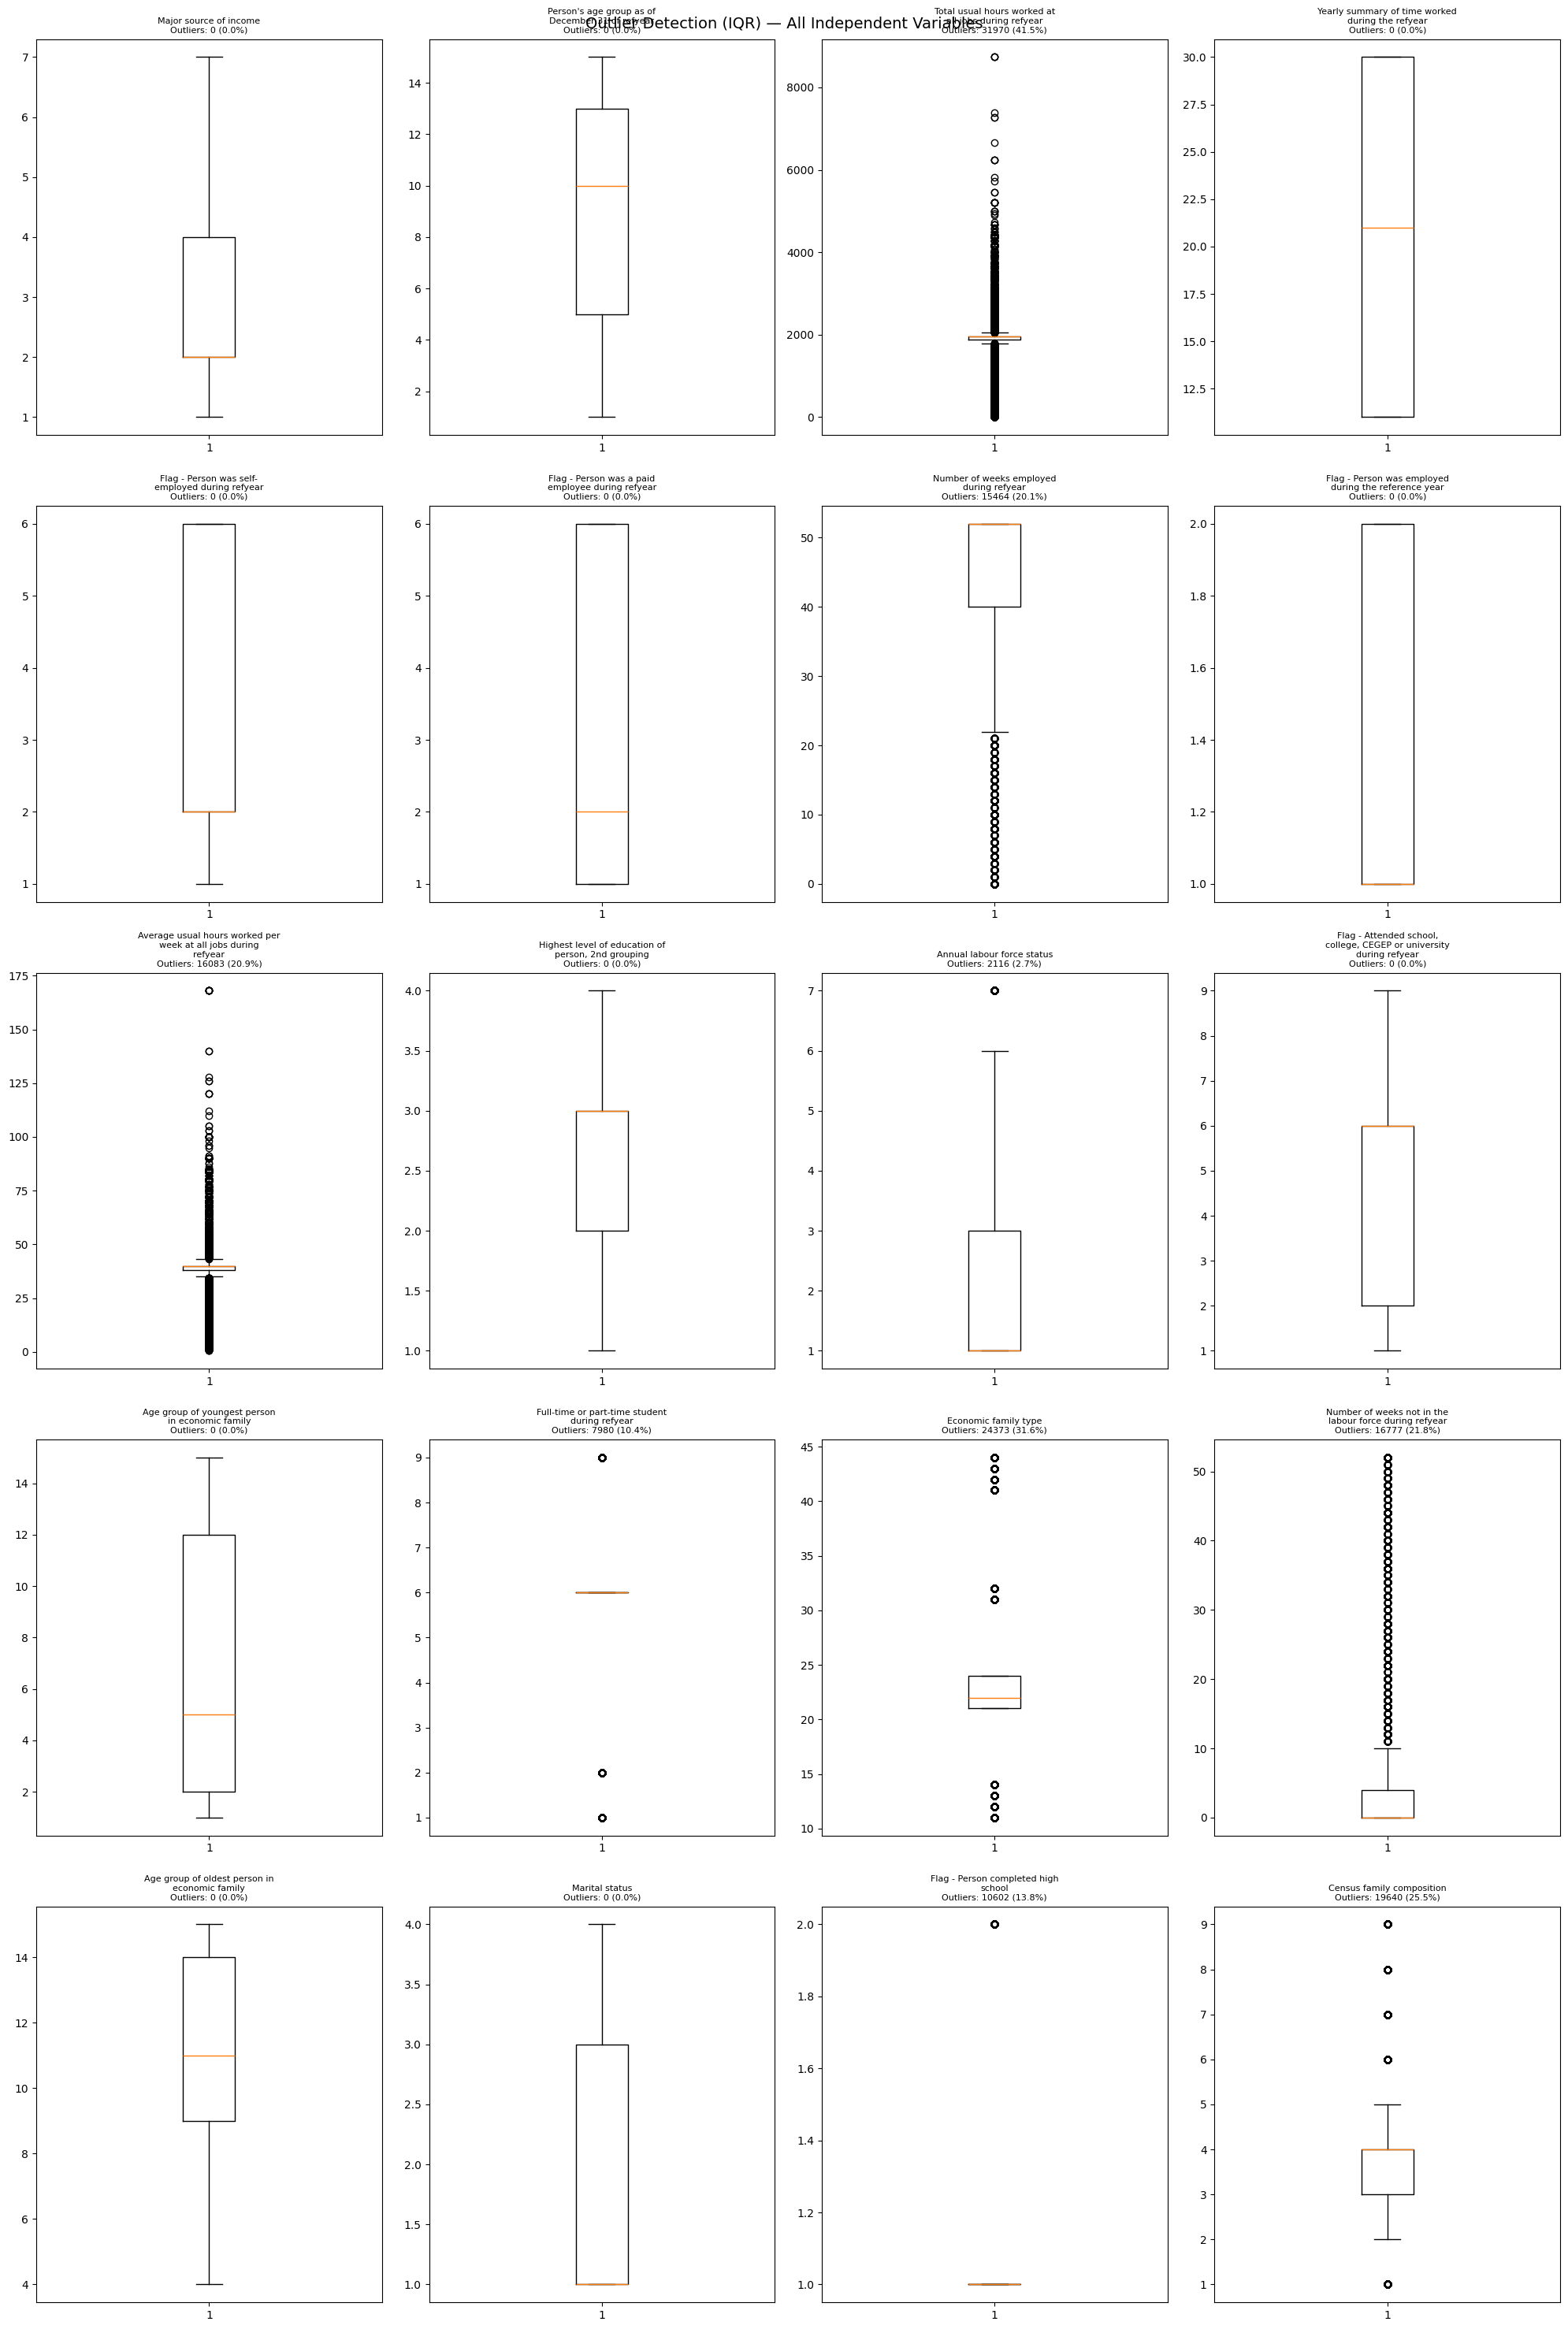

In [6]:
# Identifying outliers across all independent variables — Boxplots
import textwrap

fig, axes = plt.subplots(5, 4, figsize=(20, 30))
for i, col in enumerate(features):
    ax = axes[i // 4][i % 4]
    ax.boxplot(X_train[col].dropna(), vert=True)
    q1 = X_train[col].quantile(0.25)
    q3 = X_train[col].quantile(0.75)
    iqr = q3 - q1
    n_out = ((X_train[col] < q1 - 1.5*iqr) | (X_train[col] > q3 + 1.5*iqr)).sum()
    pct = n_out / len(X_train) * 100
    wrapped = textwrap.fill(col, width=30)
    ax.set_title(f'{wrapped}\nOutliers: {n_out} ({pct:.1f}%)', fontsize=8)
plt.suptitle('Outlier Detection (IQR) — All Independent Variables', fontsize=14)
plt.tight_layout()
plt.show()

In [7]:
# Feature outlier summary (IQR method)
outlier_summary = []
for col in features:
    q1 = X_train[col].quantile(0.25)
    q3 = X_train[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    n_outliers = ((X_train[col] < lower) | (X_train[col] > upper)).sum()
    pct = n_outliers / len(X_train) * 100
    outlier_summary.append({
        'Feature': col[:50], 'Q1': q1, 'Q3': q3, 'IQR': iqr,
        'Outliers': n_outliers, '% Outliers': round(pct, 2),
        'Skewness': round(X_train[col].skew(), 3)
    })

outlier_df = pd.DataFrame(outlier_summary).sort_values('% Outliers', ascending=False)
outlier_df

,Feature,Q1,Q3,IQR,Outliers,% Outliers,Skewness
2,Total usual hours worked at all jobs during re...,1882.0,1950.0,68.0,31970,41.50,-0.929
14,Economic family type,21.0,24.0,3.0,24373,31.64,1.183
19,Census family composition,3.0,4.0,1.0,19640,25.49,0.473
15,Number of weeks not in the labour force during...,0.0,4.0,4.0,16777,21.78,1.635
8,Average usual hours worked per week at all job...,38.0,40.0,2.0,16083,20.88,-0.285
6,Number of weeks employed during refyear,40.0,52.0,12.0,15464,20.07,-1.372
18,Flag - Person completed high school,1.0,1.0,0.0,10602,13.76,2.104
13,Full-time or part-time student during refyear,6.0,6.0,0.0,7980,10.36,-2.474
10,Annual labour force status,1.0,3.0,2.0,2116,2.75,1.463
3,Yearly summary of time worked during the refyear,11.0,30.0,19.0,0,0.00,-0.047


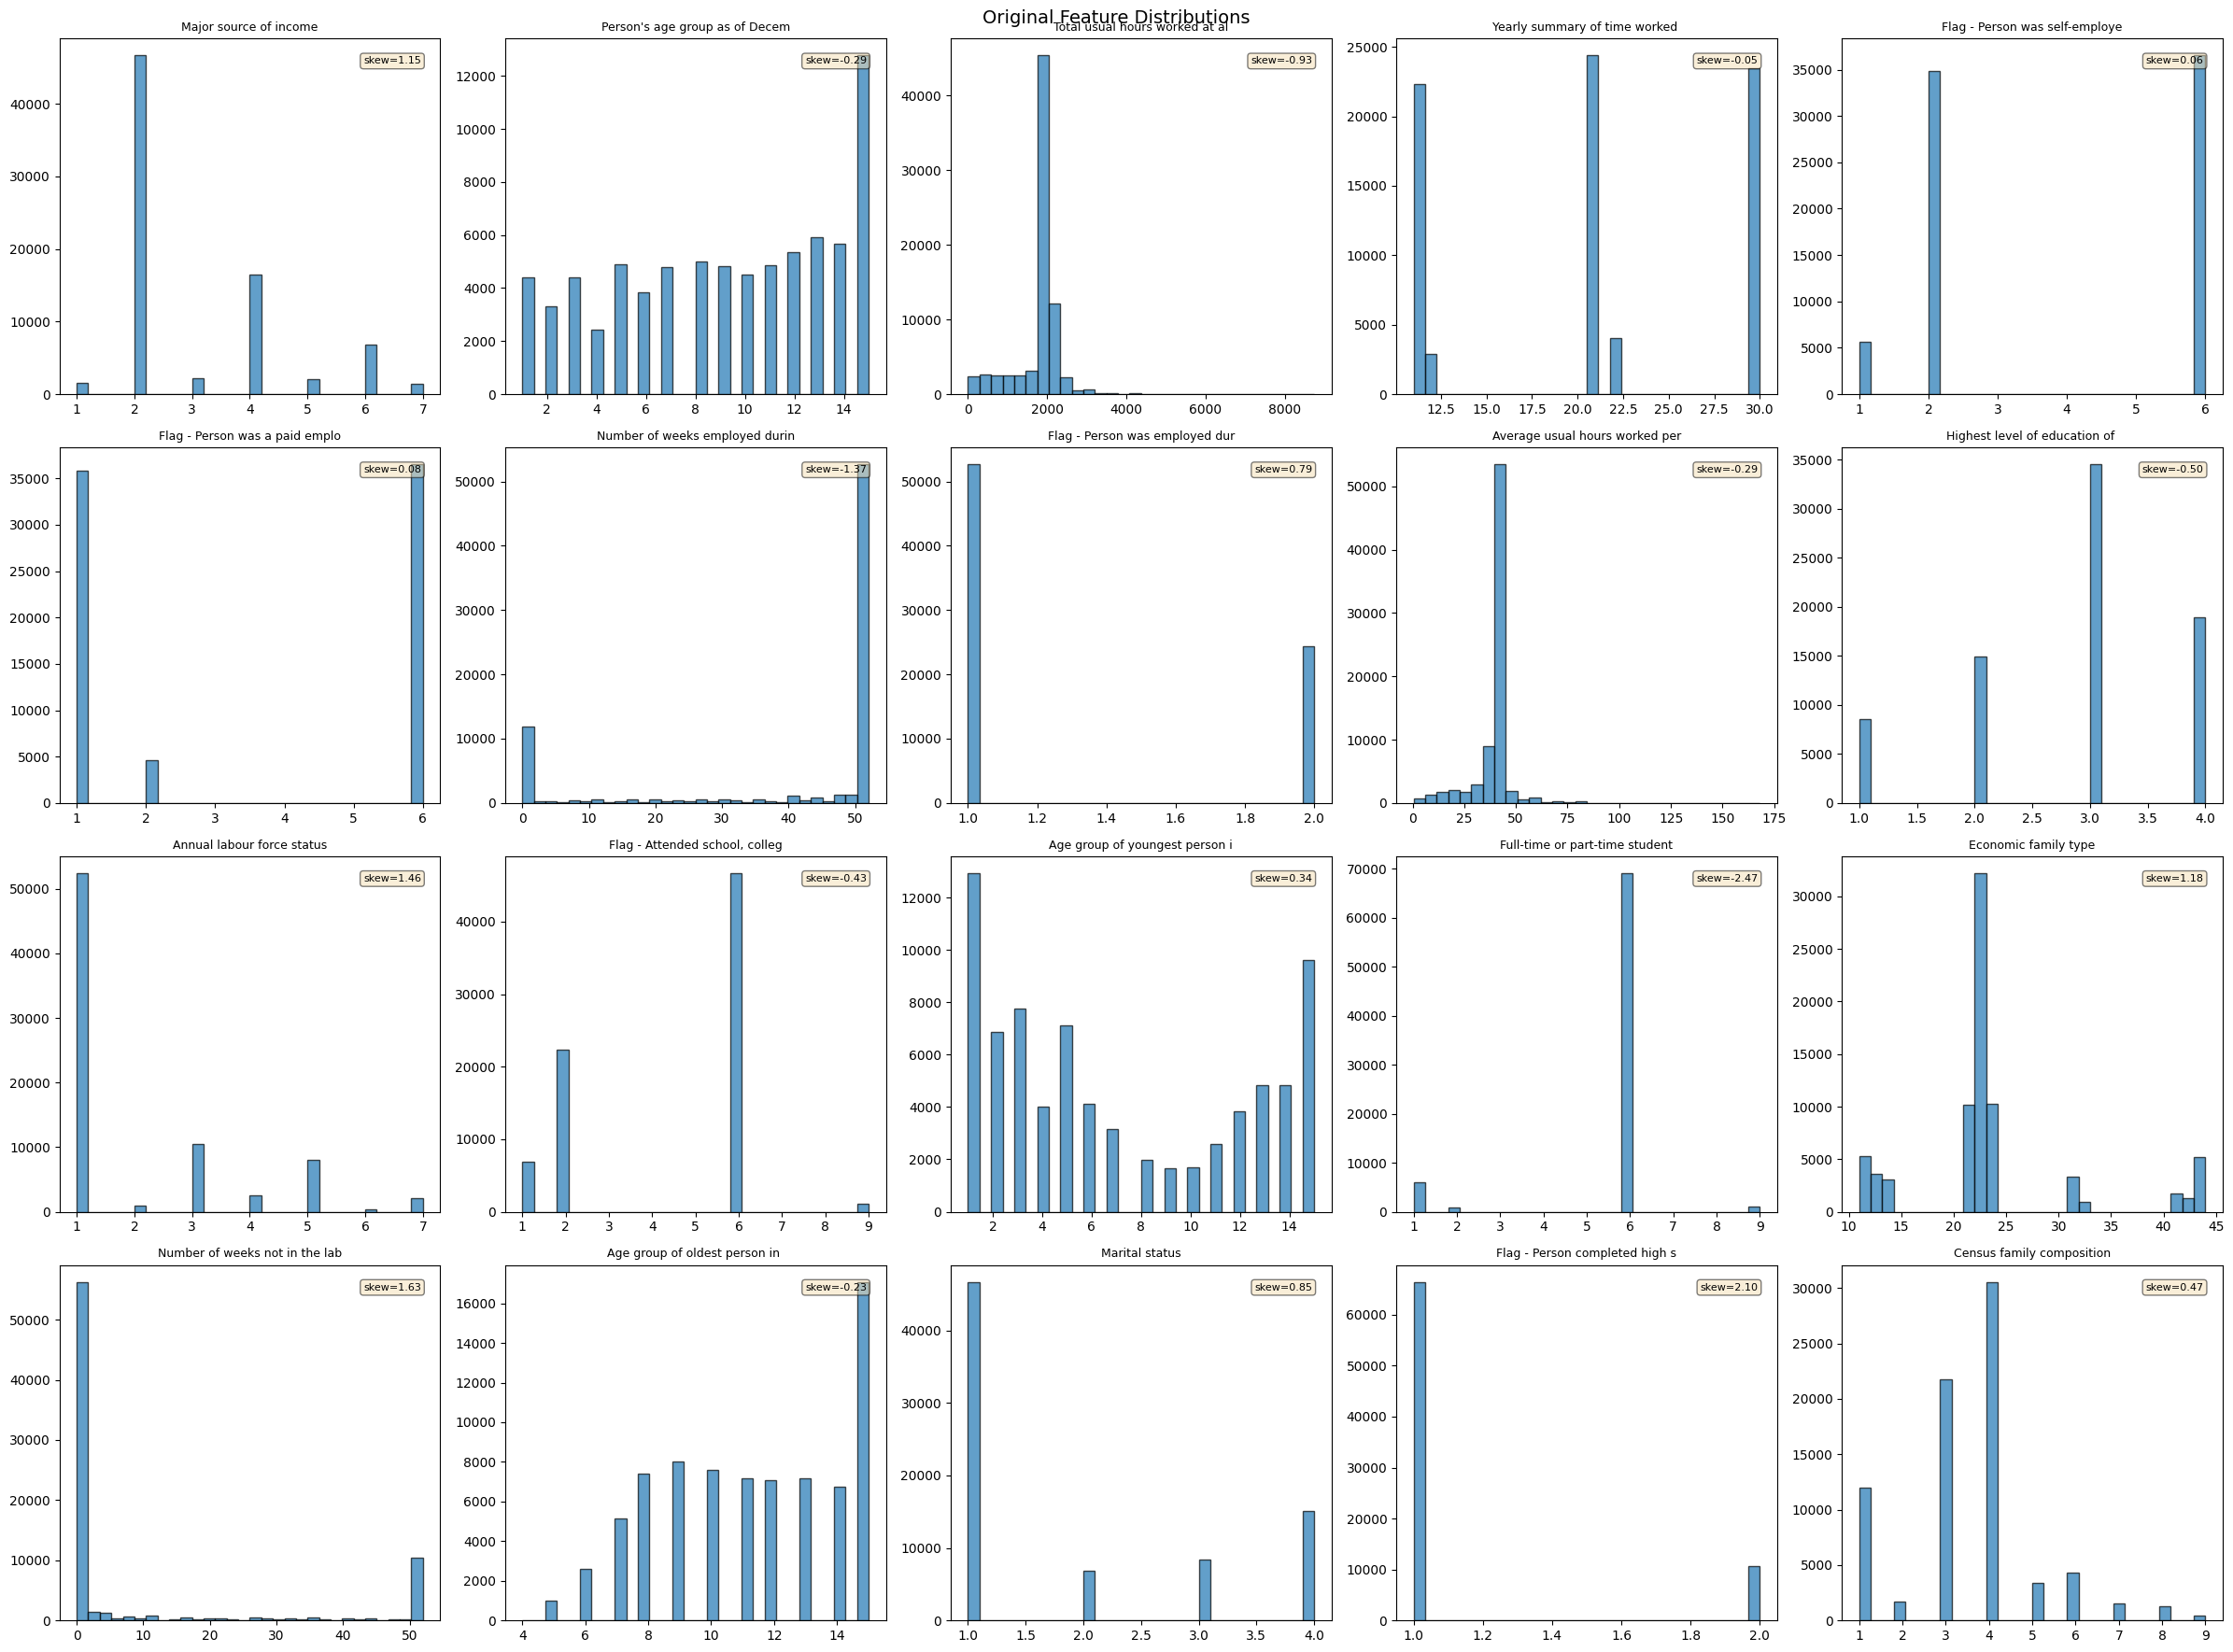

In [8]:
# Feature distributions — original
fig, axes = plt.subplots(4, 5, figsize=(24, 18))
for i, col in enumerate(features):
    ax = axes[i // 5][i % 5]
    ax.hist(X_train[col], bins=30, edgecolor='black', alpha=0.7)
    ax.set_title(col[:30], fontsize=9)
    ax.text(0.95, 0.95, f'skew={X_train[col].skew():.2f}',
            transform=ax.transAxes, ha='right', va='top', fontsize=8,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
plt.suptitle('Original Feature Distributions', fontsize=14)
plt.tight_layout()
plt.show()

## Task 1: Apply Best Transformation Per Feature

In [9]:
# 4 Transformations: Log, Square-root, Box-Cox, Robust Scaling
# For each feature, pick the one that minimizes |skewness|
# Low-cardinality features (<=10 unique) skip Box-Cox (distorts ordinal structure)
# but still try Log, Square-root, Robust Scaling

CARDINALITY_THRESHOLD = 10

def apply_log(series):
    shift = series.min()
    if shift <= 0:
        shifted = series - shift + 1
    else:
        shifted = series
    return np.log1p(shifted), 'Log'

def apply_sqrt(series):
    shift = series.min()
    if shift < 0:
        shifted = series - shift
    else:
        shifted = series
    return np.sqrt(shifted), 'Square-root'

def apply_boxcox(series):
    shift = series.min()
    if shift <= 0:
        shifted = series - shift + 1
    else:
        shifted = series
    try:
        transformed, _ = stats.boxcox(shifted)
        return pd.Series(transformed, index=series.index), 'Box-Cox'
    except:
        return series, 'Box-Cox (failed)'

def apply_robust(series):
    scaler = RobustScaler()
    transformed = scaler.fit_transform(series.values.reshape(-1, 1)).flatten()
    return pd.Series(transformed, index=series.index), 'Robust Scaling'

all_transformations = [apply_log, apply_sqrt, apply_boxcox, apply_robust]
no_boxcox = [apply_log, apply_sqrt, apply_robust]

best_transforms = {}
transform_results = {}

for col in features:
    n_unique = X_train[col].nunique()
    original_skew = abs(X_train[col].skew())

    # Use all 4 for continuous features, exclude Box-Cox for low-cardinality
    candidates = all_transformations if n_unique > CARDINALITY_THRESHOLD else no_boxcox

    best_skew = original_skew
    best_name = 'None (Original)'
    best_data = X_train[col]

    for func in candidates:
        transformed, name = func(X_train[col])
        skew = abs(transformed.skew())
        if skew < best_skew:
            best_skew = skew
            best_name = name
            best_data = transformed

    best_transforms[col] = best_name
    transform_results[col] = {
        'original_skew': round(X_train[col].skew(), 3),
        'new_skew': round(best_data.skew(), 3),
        'transform': best_name
    }

transform_summary = pd.DataFrame(transform_results).T
transform_summary.index.name = 'Feature'
transform_summary

,original_skew,new_skew,transform
Feature,,,
Major source of income,1.148,0.765,Log
Person's age group as of December 31 of refyear,-0.291,-0.291,None (Original)
Total usual hours worked at all jobs during refyear,-0.929,0.564,Box-Cox
Yearly summary of time worked during the refyear,-0.047,-0.047,None (Original)
Flag - Person was self-employed during refyear,0.055,-0.018,Square-root
Flag - Person was a paid employee during refyear,0.08,0.046,Log
Number of weeks employed during refyear,-1.372,-1.309,Box-Cox
Flag - Person was employed during the reference year,0.789,0.789,Robust Scaling
Average usual hours worked per week at all jobs during refyear,-0.285,-0.285,None (Original)


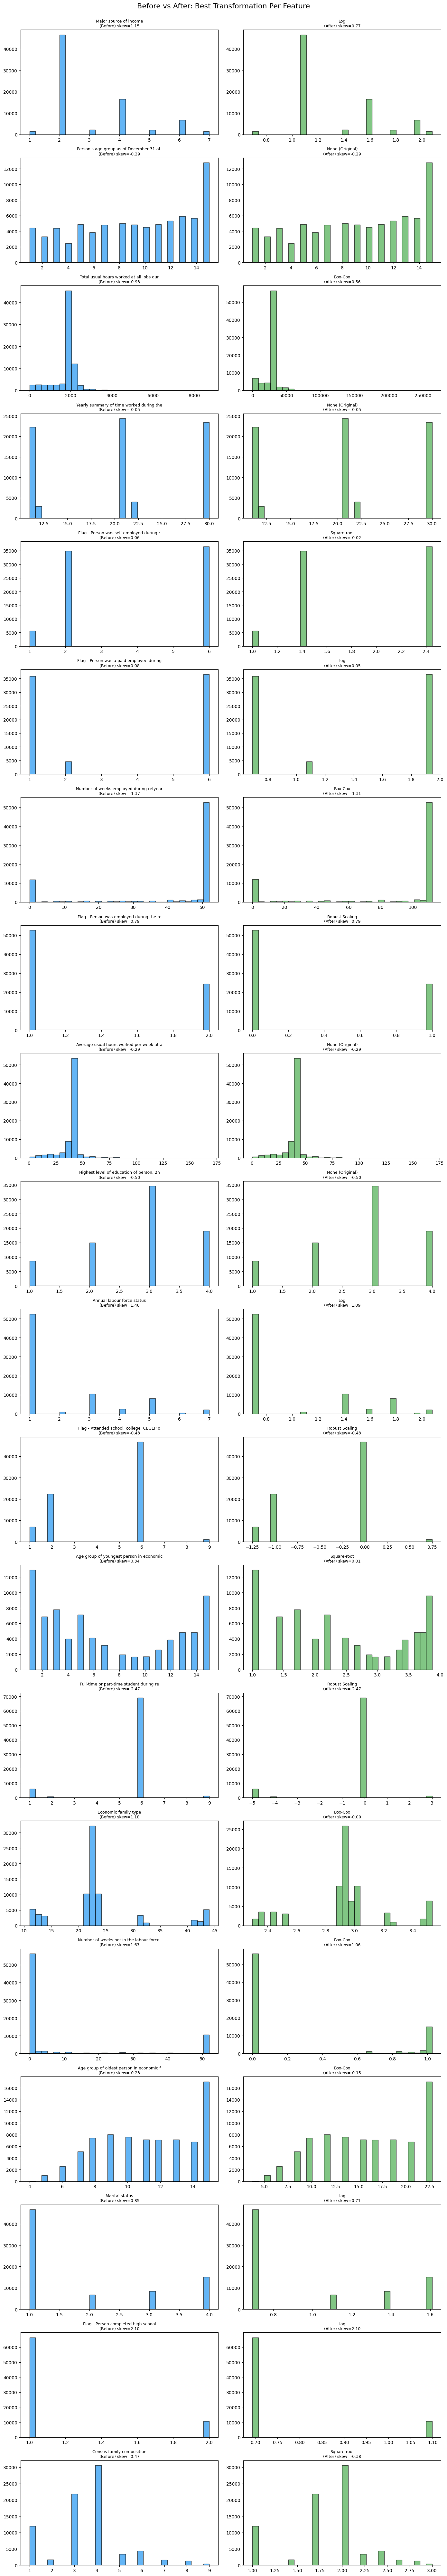

In [10]:
# 20 Before vs After graphs (one per feature, 2 columns: before | after)
fig, axes = plt.subplots(20, 2, figsize=(14, 80))

transform_funcs = {
    'Log': apply_log,
    'Square-root': apply_sqrt,
    'Box-Cox': apply_boxcox,
    'Robust Scaling': apply_robust,
    'None (Original)': lambda s: (s, 'Original'),
}

for i, col in enumerate(features):
    # Before
    axes[i][0].hist(X_train[col], bins=30, edgecolor='black', alpha=0.7, color='#2196F3')
    axes[i][0].set_title(f'{col[:40]}\n(Before) skew={X_train[col].skew():.2f}', fontsize=9)

    # After
    best_name = best_transforms[col]
    func = transform_funcs[best_name]
    transformed, _ = func(X_train[col])
    axes[i][1].hist(transformed, bins=30, edgecolor='black', alpha=0.7, color='#4CAF50')
    axes[i][1].set_title(f'{best_name}\n(After) skew={transformed.skew():.2f}', fontsize=9)

plt.suptitle('Before vs After: Best Transformation Per Feature', fontsize=16, y=1.0)
plt.tight_layout()
plt.show()

In [11]:
# Build transformed train and test sets
def transform_dataset(X_data, best_transforms_map):
    X_new = X_data.copy()
    for col in X_data.columns:
        best_name = best_transforms_map[col]
        if best_name == 'None (Original)':
            continue
        func = transform_funcs[best_name]
        X_new[col], _ = func(X_data[col])
    return X_new

X_train_transformed = transform_dataset(X_train, best_transforms)
X_test_transformed = transform_dataset(X_test, best_transforms)

print('Transformed train shape:', X_train_transformed.shape)
print('Transformed test shape:', X_test_transformed.shape)

Transformed train shape: (77041, 20)
Transformed test shape: (19261, 20)


## Model Performance: Before vs After Transformation

In [12]:
# Models on transformed features — test on original test set
# StandardScaler for SVR on transformed data
scaler_transformed = StandardScaler()
X_train_trans_scaled = pd.DataFrame(scaler_transformed.fit_transform(X_train_transformed), columns=X_train_transformed.columns, index=X_train_transformed.index)
X_test_trans_scaled = pd.DataFrame(scaler_transformed.transform(X_test_transformed), columns=X_test_transformed.columns, index=X_test_transformed.index)

transformed_models = {
    'Decision Tree': (DecisionTreeRegressor(random_state=42), X_train_transformed, X_test_transformed),
    'Random Forest': (RandomForestRegressor(n_estimators=100, random_state=42), X_train_transformed, X_test_transformed),
    'SVR': (SVR(), X_train_trans_scaled, X_test_trans_scaled),
}

transformed_results = {}
for name, (model, X_tr, X_te) in transformed_models.items():
    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)
    transformed_results[name] = evaluate(y_test, y_pred, n_feat)

transformed_df = pd.DataFrame(transformed_results).T
transformed_df

,R2,Adj_R2,RMSE,MAE,MAPE
Decision Tree,-1.3159,-1.3183,54531.87,31854.49,357.86
Random Forest,0.0356,0.0346,35190.31,24517.94,379.65
SVR,0.0255,0.0245,35373.75,20928.65,314.87


In [13]:
# Before vs After comparison table
comparison = pd.DataFrame({
    'DT (Before)': baseline_results['Decision Tree'],
    'DT (After)': transformed_results['Decision Tree'],
    'RF (Before)': baseline_results['Random Forest'],
    'RF (After)': transformed_results['Random Forest'],
    'SVR (Before)': baseline_results['SVR'],
    'SVR (After)': transformed_results['SVR'],
}).T
comparison

,R2,Adj_R2,RMSE,MAE,MAPE
DT (Before),-0.0417,-0.0428,36572.94,17924.70,227.53
DT (After),-1.3159,-1.3183,54531.87,31854.49,357.86
RF (Before),0.2981,0.2973,30021.87,15305.30,209.73
RF (After),0.0356,0.0346,35190.31,24517.94,379.65
SVR (Before),0.0427,0.0417,35060.71,20678.50,312.95
SVR (After),0.0255,0.0245,35373.75,20928.65,314.87


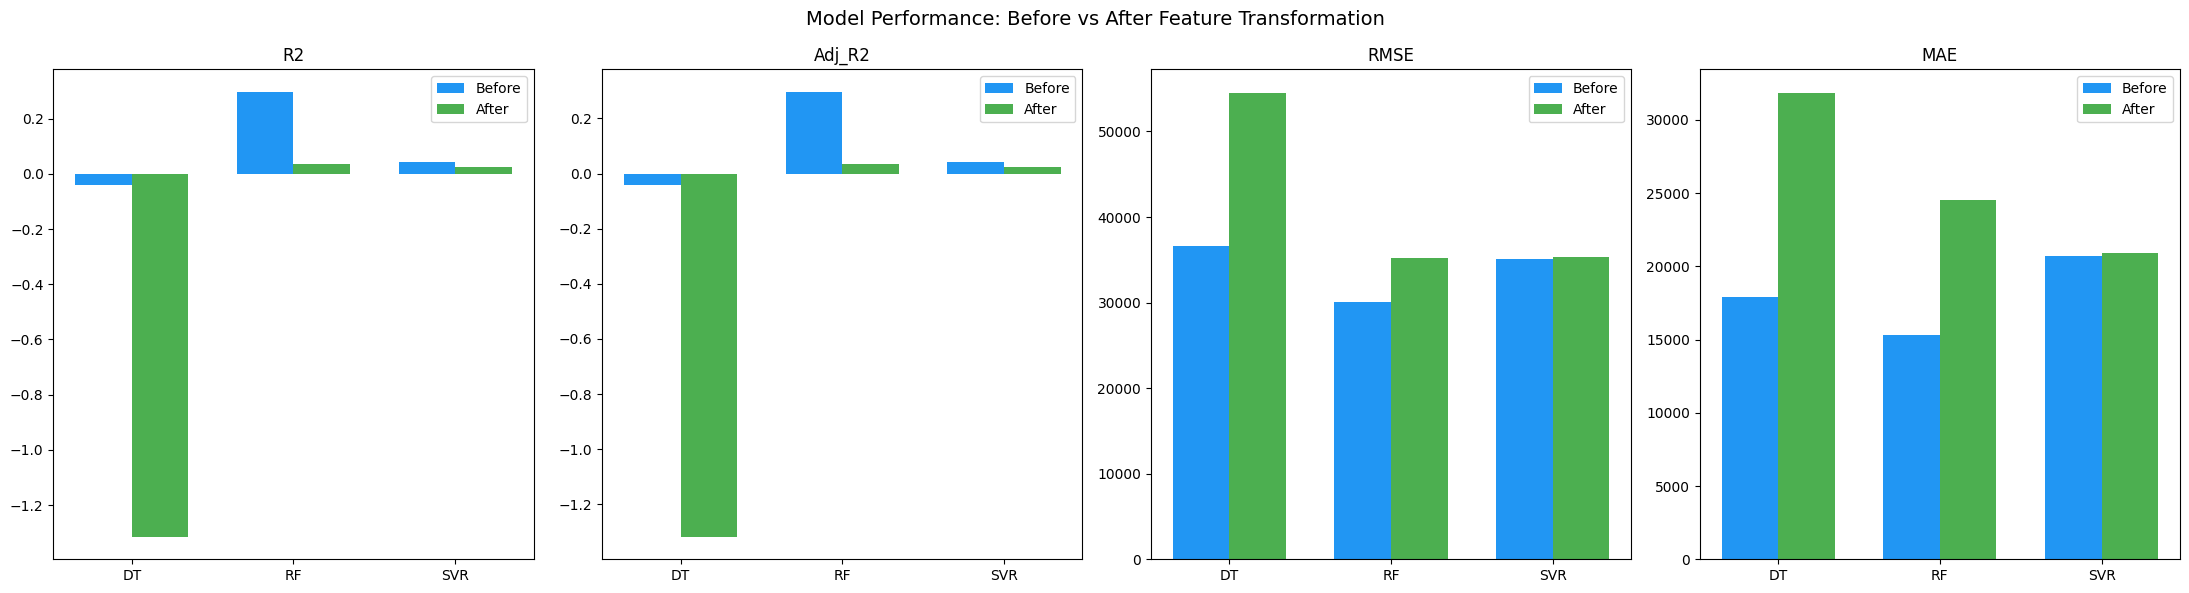

In [14]:
# Visual comparison: Before vs After for each metric
fig, axes = plt.subplots(1, 4, figsize=(22, 6))
metrics = ['R2', 'Adj_R2', 'RMSE', 'MAE']
model_names = ['Decision Tree', 'Random Forest', 'SVR']
x = np.arange(len(model_names))
width = 0.35

for idx, metric in enumerate(metrics):
    before_vals = [baseline_results[m][metric] for m in model_names]
    after_vals = [transformed_results[m][metric] for m in model_names]

    axes[idx].bar(x - width/2, before_vals, width, label='Before', color='#2196F3')
    axes[idx].bar(x + width/2, after_vals, width, label='After', color='#4CAF50')
    axes[idx].set_title(metric)
    axes[idx].set_xticks(x)
    axes[idx].set_xticklabels(['DT', 'RF', 'SVR'])
    axes[idx].legend()

plt.suptitle('Model Performance: Before vs After Feature Transformation', fontsize=14)
plt.tight_layout()
plt.show()

## Task 2: Hyperparameter Explanation

In [15]:
# Use transformed data for hyperparameter analysis
# Sample for SVR speed (SVR is O(n^2) so full dataset is slow)
from sklearn.model_selection import validation_curve

sample_idx = np.random.RandomState(42).choice(len(X_train_transformed), size=5000, replace=False)
X_sample = X_train_transformed.iloc[sample_idx]
y_sample = y_train.iloc[sample_idx]

# Scaled sample for SVR
scaler_sample = StandardScaler()
X_sample_scaled = pd.DataFrame(scaler_sample.fit_transform(X_sample), columns=X_sample.columns, index=X_sample.index)

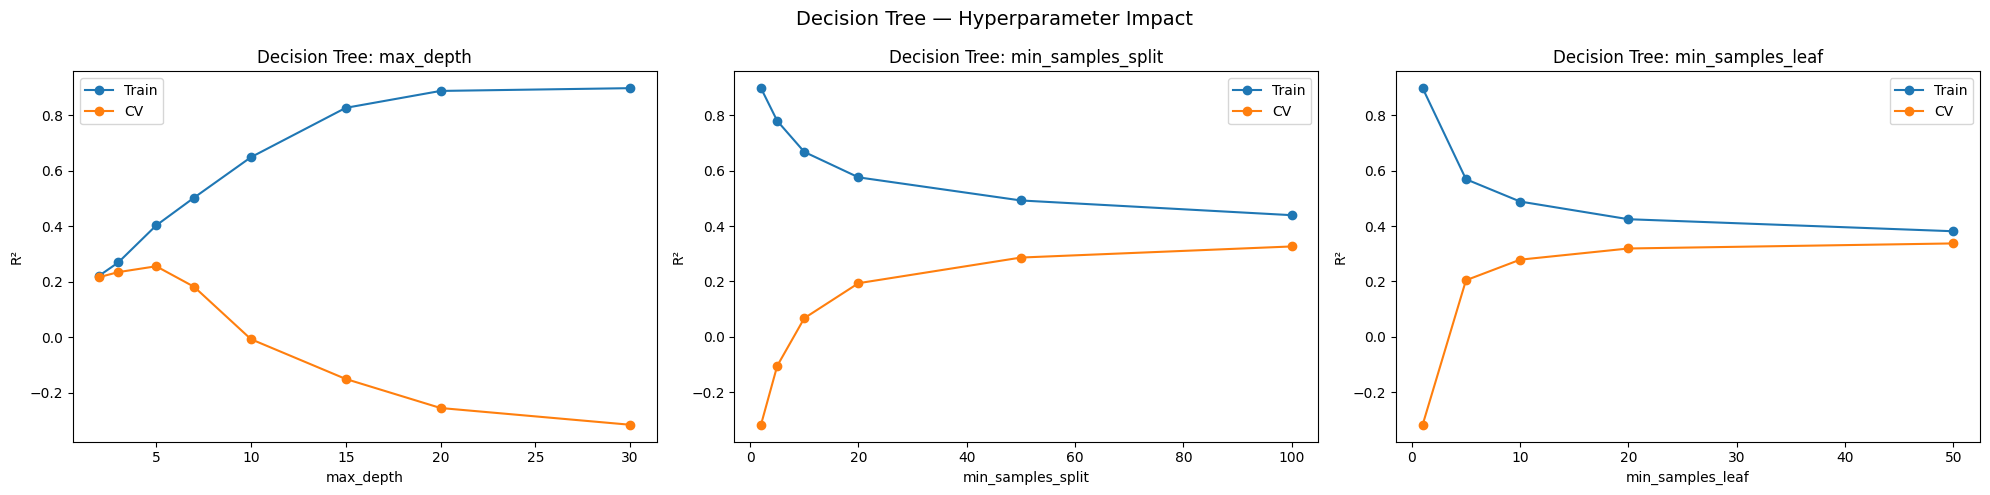

In [16]:
# Decision Tree — Validation Curves
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# max_depth
param_range = [2, 3, 5, 7, 10, 15, 20, 30]
train_scores, test_scores = validation_curve(
    DecisionTreeRegressor(random_state=42), X_sample, y_sample,
    param_name='max_depth', param_range=param_range, cv=5, scoring='r2')
axes[0].plot(param_range, train_scores.mean(axis=1), 'o-', label='Train')
axes[0].plot(param_range, test_scores.mean(axis=1), 'o-', label='CV')
axes[0].set_xlabel('max_depth')
axes[0].set_ylabel('R²')
axes[0].set_title('Decision Tree: max_depth')
axes[0].legend()

# min_samples_split
param_range2 = [2, 5, 10, 20, 50, 100]
train_scores, test_scores = validation_curve(
    DecisionTreeRegressor(random_state=42), X_sample, y_sample,
    param_name='min_samples_split', param_range=param_range2, cv=5, scoring='r2')
axes[1].plot(param_range2, train_scores.mean(axis=1), 'o-', label='Train')
axes[1].plot(param_range2, test_scores.mean(axis=1), 'o-', label='CV')
axes[1].set_xlabel('min_samples_split')
axes[1].set_ylabel('R²')
axes[1].set_title('Decision Tree: min_samples_split')
axes[1].legend()

# min_samples_leaf
param_range3 = [1, 5, 10, 20, 50]
train_scores, test_scores = validation_curve(
    DecisionTreeRegressor(random_state=42), X_sample, y_sample,
    param_name='min_samples_leaf', param_range=param_range3, cv=5, scoring='r2')
axes[2].plot(param_range3, train_scores.mean(axis=1), 'o-', label='Train')
axes[2].plot(param_range3, test_scores.mean(axis=1), 'o-', label='CV')
axes[2].set_xlabel('min_samples_leaf')
axes[2].set_ylabel('R²')
axes[2].set_title('Decision Tree: min_samples_leaf')
axes[2].legend()

plt.suptitle('Decision Tree — Hyperparameter Impact', fontsize=14)
plt.tight_layout()
plt.show()

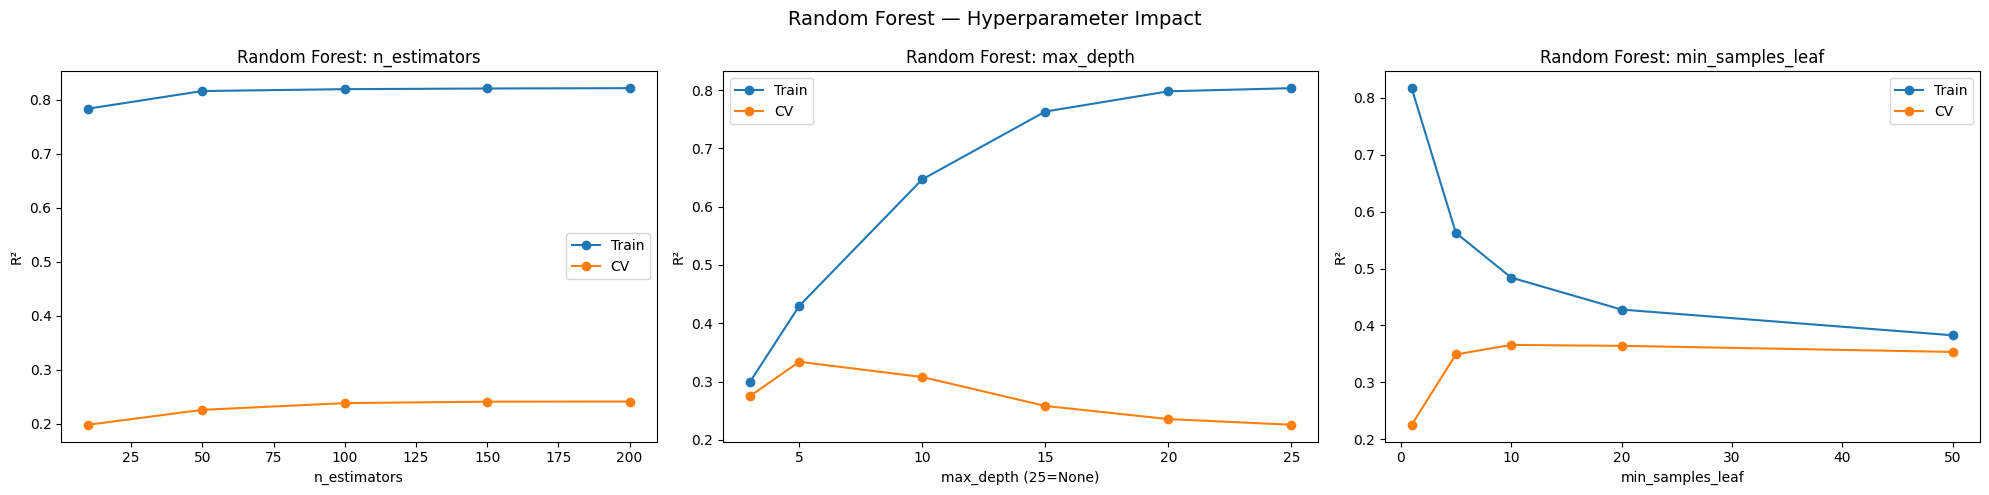

In [17]:
# Random Forest — Validation Curves
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# n_estimators
param_range = [10, 50, 100, 150, 200]
train_scores, test_scores = validation_curve(
    RandomForestRegressor(random_state=42), X_sample, y_sample,
    param_name='n_estimators', param_range=param_range, cv=5, scoring='r2')
axes[0].plot(param_range, train_scores.mean(axis=1), 'o-', label='Train')
axes[0].plot(param_range, test_scores.mean(axis=1), 'o-', label='CV')
axes[0].set_xlabel('n_estimators')
axes[0].set_ylabel('R²')
axes[0].set_title('Random Forest: n_estimators')
axes[0].legend()

# max_depth
param_range2 = [3, 5, 10, 15, 20, None]
labels2 = [3, 5, 10, 15, 20, 25]
train_scores_list, test_scores_list = [], []
for d in param_range2:
    rf = RandomForestRegressor(n_estimators=50, max_depth=d, random_state=42)
    scores = cross_val_score(rf, X_sample, y_sample, cv=5, scoring='r2')
    rf.fit(X_sample, y_sample)
    train_scores_list.append(rf.score(X_sample, y_sample))
    test_scores_list.append(scores.mean())
axes[1].plot(labels2, train_scores_list, 'o-', label='Train')
axes[1].plot(labels2, test_scores_list, 'o-', label='CV')
axes[1].set_xlabel('max_depth (25=None)')
axes[1].set_ylabel('R²')
axes[1].set_title('Random Forest: max_depth')
axes[1].legend()

# min_samples_leaf
param_range3 = [1, 5, 10, 20, 50]
train_scores, test_scores = validation_curve(
    RandomForestRegressor(n_estimators=50, random_state=42), X_sample, y_sample,
    param_name='min_samples_leaf', param_range=param_range3, cv=5, scoring='r2')
axes[2].plot(param_range3, train_scores.mean(axis=1), 'o-', label='Train')
axes[2].plot(param_range3, test_scores.mean(axis=1), 'o-', label='CV')
axes[2].set_xlabel('min_samples_leaf')
axes[2].set_ylabel('R²')
axes[2].set_title('Random Forest: min_samples_leaf')
axes[2].legend()

plt.suptitle('Random Forest — Hyperparameter Impact', fontsize=14)
plt.tight_layout()
plt.show()

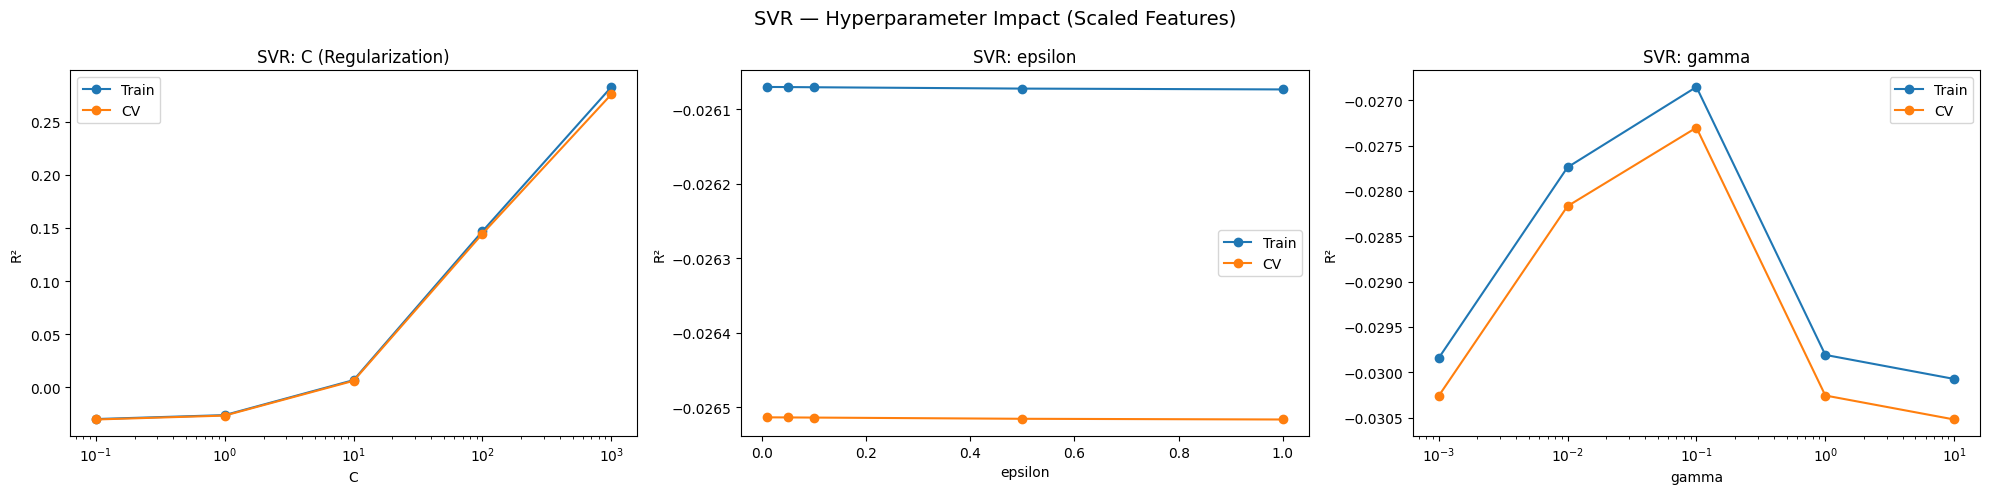

In [18]:
# SVR — Validation Curves (using scaled sample)
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# C
param_range = [0.1, 1, 10, 100, 1000]
train_scores, test_scores = validation_curve(
    SVR(kernel='rbf'), X_sample_scaled, y_sample,
    param_name='C', param_range=param_range, cv=5, scoring='r2')
axes[0].plot(param_range, train_scores.mean(axis=1), 'o-', label='Train')
axes[0].plot(param_range, test_scores.mean(axis=1), 'o-', label='CV')
axes[0].set_xlabel('C')
axes[0].set_xscale('log')
axes[0].set_ylabel('R²')
axes[0].set_title('SVR: C (Regularization)')
axes[0].legend()

# epsilon
param_range2 = [0.01, 0.05, 0.1, 0.5, 1.0]
train_scores, test_scores = validation_curve(
    SVR(kernel='rbf'), X_sample_scaled, y_sample,
    param_name='epsilon', param_range=param_range2, cv=5, scoring='r2')
axes[1].plot(param_range2, train_scores.mean(axis=1), 'o-', label='Train')
axes[1].plot(param_range2, test_scores.mean(axis=1), 'o-', label='CV')
axes[1].set_xlabel('epsilon')
axes[1].set_ylabel('R²')
axes[1].set_title('SVR: epsilon')
axes[1].legend()

# gamma
param_range3 = [0.001, 0.01, 0.1, 1, 10]
train_scores, test_scores = validation_curve(
    SVR(kernel='rbf'), X_sample_scaled, y_sample,
    param_name='gamma', param_range=param_range3, cv=5, scoring='r2')
axes[2].plot(param_range3, train_scores.mean(axis=1), 'o-', label='Train')
axes[2].plot(param_range3, test_scores.mean(axis=1), 'o-', label='CV')
axes[2].set_xlabel('gamma')
axes[2].set_xscale('log')
axes[2].set_ylabel('R²')
axes[2].set_title('SVR: gamma')
axes[2].legend()

plt.suptitle('SVR — Hyperparameter Impact (Scaled Features)', fontsize=14)
plt.tight_layout()
plt.show()

In [19]:
import gc

del baseline_models, transformed_models
del outlier_summary, outlier_df, transform_summary
del X_sample, y_sample, X_sample_scaled
gc.collect()

330867

## Task 3: Hyperparameter Tuning (GridSearchCV)
### Using original (untransformed) data — Task 1 showed transformations hurt tree-based models

In [20]:
# Decision Tree — GridSearchCV
# Parameter grid informed by Task 2 validation curves
# max_depth: CV R² peaked at moderate depth (5-15)
# min_samples_split: higher values reduce overfitting
# min_samples_leaf: moderate values prevent memorization

dt_param_grid = {
    'max_depth': [5, 7, 10, 15, 20],
    'min_samples_split': [10, 20, 50],
    'min_samples_leaf': [5, 10, 20],
}

# Total combinations: 5 × 3 × 3 = 45
print(f"Decision Tree: {5*3*3} parameter combinations")

dt_grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    dt_param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    return_train_score=True
)

dt_grid.fit(X_train, y_train)

print(f"Best Parameters: {dt_grid.best_params_}")
print(f"Best CV R²: {dt_grid.best_score_:.4f}")

# Evaluate on test set
dt_best = dt_grid.best_estimator_
dt_pred = dt_best.predict(X_test)
dt_tuned_results = evaluate(y_test, dt_pred, n_feat)
print(f"Test Results: {dt_tuned_results}")

Decision Tree: 45 parameter combinations
Best Parameters: {'max_depth': 10, 'min_samples_leaf': 20, 'min_samples_split': 50}
Best CV R²: 0.3558
Test Results: {'R2': 0.4041, 'Adj_R2': 0.4035, 'RMSE': np.float64(27660.45), 'MAE': 14501.23, 'MAPE': np.float64(187.99)}


In [21]:
# Random Forest — GridSearchCV
# n_estimators: diminishing returns after ~100 (from Task 2 curves)
# max_depth: CV peaks at moderate depth
# min_samples_leaf: prevents overfitting to outliers

rf_param_grid = {
    'n_estimators': [100, 150, 200],
    'max_depth': [10, 15, 20, None],
    'min_samples_leaf': [1, 5, 10],
}

# Total combinations: 3 × 4 × 3 = 36
print(f"Random Forest: {3*4*3} parameter combinations")

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    rf_param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    return_train_score=True
)

rf_grid.fit(X_train, y_train)

print(f"Best Parameters: {rf_grid.best_params_}")
print(f"Best CV R²: {rf_grid.best_score_:.4f}")

# Evaluate on test set
rf_best = rf_grid.best_estimator_
rf_pred = rf_best.predict(X_test)
rf_tuned_results = evaluate(y_test, rf_pred, n_feat)
print(f"Test Results: {rf_tuned_results}")

Random Forest: 36 parameter combinations
Best Parameters: {'max_depth': 15, 'min_samples_leaf': 10, 'n_estimators': 200}
Best CV R²: 0.3817
Test Results: {'R2': 0.4249, 'Adj_R2': 0.4243, 'RMSE': np.float64(27175.58), 'MAE': 14055.69, 'MAPE': np.float64(180.24)}


In [22]:
# SVR — GridSearchCV (using scaled data, sampled for speed)
# C: moderate values avoid overfitting (from Task 2 curves)
# epsilon: controls insensitive tube width
# gamma: high gamma overfits — keep moderate/low

# SVR is O(n²) — sample 5000 rows for tractable GridSearch
sample_idx = np.random.RandomState(42).choice(len(X_train), size=5000, replace=False)
X_svr_sample = X_train_scaled.iloc[sample_idx]
y_svr_sample = y_train.iloc[sample_idx]

svr_param_grid = {
    'C': [1, 10, 100, 1000],
    'epsilon': [0.01, 0.1, 0.5],
    'gamma': ['scale', 0.01, 0.1],
}

# Total combinations: 4 × 3 × 3 = 36
print(f"SVR: {4*3*3} parameter combinations")

svr_grid = GridSearchCV(
    SVR(kernel='rbf'),
    svr_param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    return_train_score=True
)

svr_grid.fit(X_svr_sample, y_svr_sample)

print(f"Best Parameters: {svr_grid.best_params_}")
print(f"Best CV R²: {svr_grid.best_score_:.4f}")

# Evaluate on full test set (scaled)
svr_best = svr_grid.best_estimator_
svr_pred = svr_best.predict(X_test_scaled)
svr_tuned_results = evaluate(y_test, svr_pred, n_feat)
print(f"Test Results: {svr_tuned_results}")

SVR: 36 parameter combinations
Best Parameters: {'C': 1000, 'epsilon': 0.5, 'gamma': 'scale'}
Best CV R²: 0.2830
Test Results: {'R2': 0.3075, 'Adj_R2': 0.3068, 'RMSE': np.float64(29819.04), 'MAE': 15401.7, 'MAPE': np.float64(186.92)}


In [23]:
# GridSearchCV Summary Table — Best Parameters & Results
grid_summary = pd.DataFrame({
    'Decision Tree': {
        'best_max_depth': dt_grid.best_params_['max_depth'],
        'best_min_samples_split': dt_grid.best_params_['min_samples_split'],
        'best_min_samples_leaf': dt_grid.best_params_['min_samples_leaf'],
        'best_CV_R2': round(dt_grid.best_score_, 4),
        'test_R2': dt_tuned_results['R2'],
        'test_RMSE': dt_tuned_results['RMSE'],
        'test_MAE': dt_tuned_results['MAE'],
    },
    'Random Forest': {
        'best_max_depth': rf_grid.best_params_['max_depth'],
        'best_min_samples_split': '-',
        'best_min_samples_leaf': rf_grid.best_params_['min_samples_leaf'],
        'best_n_estimators': rf_grid.best_params_['n_estimators'],
        'best_CV_R2': round(rf_grid.best_score_, 4),
        'test_R2': rf_tuned_results['R2'],
        'test_RMSE': rf_tuned_results['RMSE'],
        'test_MAE': rf_tuned_results['MAE'],
    },
    'SVR': {
        'best_C': svr_grid.best_params_['C'],
        'best_epsilon': svr_grid.best_params_['epsilon'],
        'best_gamma': svr_grid.best_params_['gamma'],
        'best_CV_R2': round(svr_grid.best_score_, 4),
        'test_R2': svr_tuned_results['R2'],
        'test_RMSE': svr_tuned_results['RMSE'],
        'test_MAE': svr_tuned_results['MAE'],
    },
})
grid_summary

,Decision Tree,Random Forest,SVR
best_max_depth,10.0000,15,NaN
best_min_samples_split,50.0000,-,NaN
best_min_samples_leaf,20.0000,10,NaN
best_CV_R2,0.3558,0.3817,0.283
test_R2,0.4041,0.4249,0.3075
test_RMSE,27660.4500,27175.58,29819.04
test_MAE,14501.2300,14055.69,15401.7
best_n_estimators,NaN,200,NaN
best_C,NaN,NaN,1000
best_epsilon,NaN,NaN,0.5


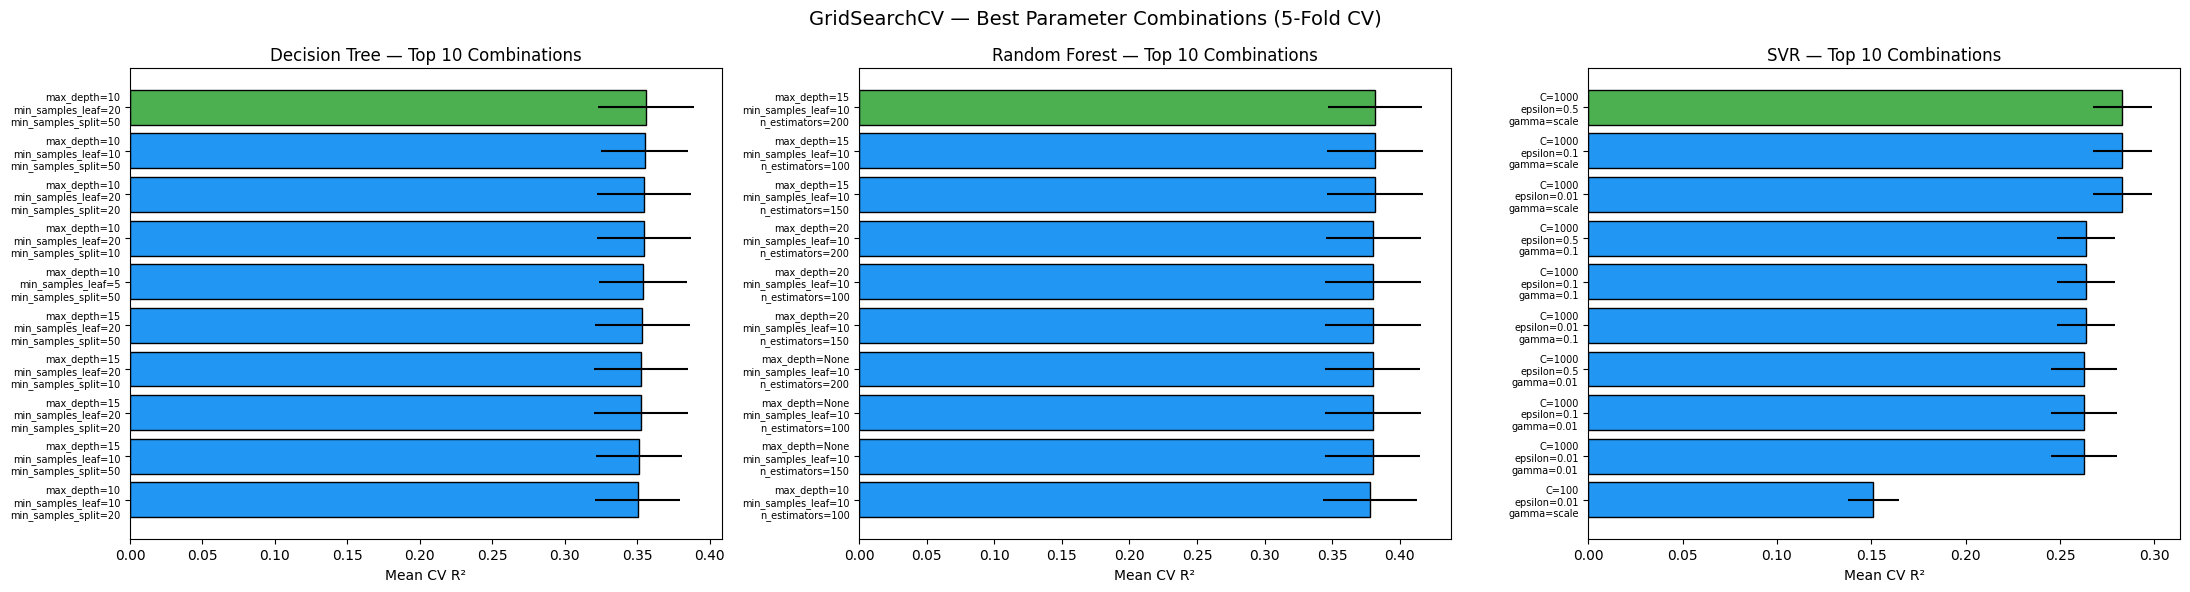

In [26]:
# GridSearchCV — Top 10 Combinations per Model (heatmap-style)
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

for idx, (name, grid) in enumerate([('Decision Tree', dt_grid), ('Random Forest', rf_grid), ('SVR', svr_grid)]):
  results = pd.DataFrame(grid.cv_results_)
  results = results.sort_values('rank_test_score').head(10)

  params_str = results['params'].apply(lambda x: '\n'.join([f'{k}={v}' for k, v in x.items()]))

  axes[idx].barh(range(10), results['mean_test_score'], xerr=results['std_test_score'],
                 color=['#4CAF50' if i == 0 else '#2196F3' for i in range(10)], edgecolor='black')
  axes[idx].set_yticks(range(10))
  axes[idx].set_yticklabels(params_str, fontsize=7)
  axes[idx].set_xlabel('Mean CV R²')
  axes[idx].set_title(f'{name} — Top 10 Combinations')
  axes[idx].invert_yaxis()

plt.suptitle('GridSearchCV — Best Parameter Combinations (5-Fold CV)', fontsize=14)
plt.tight_layout()
plt.show()

In [28]:
# Master Summary Table — All Models × All Stages
tuned_map = {
  'Decision Tree': dt_tuned_results,
  'Random Forest': rf_tuned_results,
  'SVR': svr_tuned_results,
}

rows = []
model_names = ['Decision Tree', 'Random Forest', 'SVR']
for model in model_names:
  for stage, src in [('Baseline', baseline_results), ('Transformed', transformed_results), ('Tuned', tuned_map)]:
      r = src[model]
      rows.append({'Model': model, 'Stage': stage, **r})

summary_df = pd.DataFrame(rows).set_index(['Model', 'Stage'])

def style_summary(col):
  if col.name in ['R2', 'Adj_R2']:
      best_val, worst_val = col.max(), col.min()
  else:
      best_val, worst_val = col.min(), col.max()
  return ['background-color: #c6efce; font-weight: bold' if v == best_val
          else 'background-color: #ffc7ce' if v == worst_val
          else '' for v in col]

summary_df.style.apply(style_summary).format(precision=2)

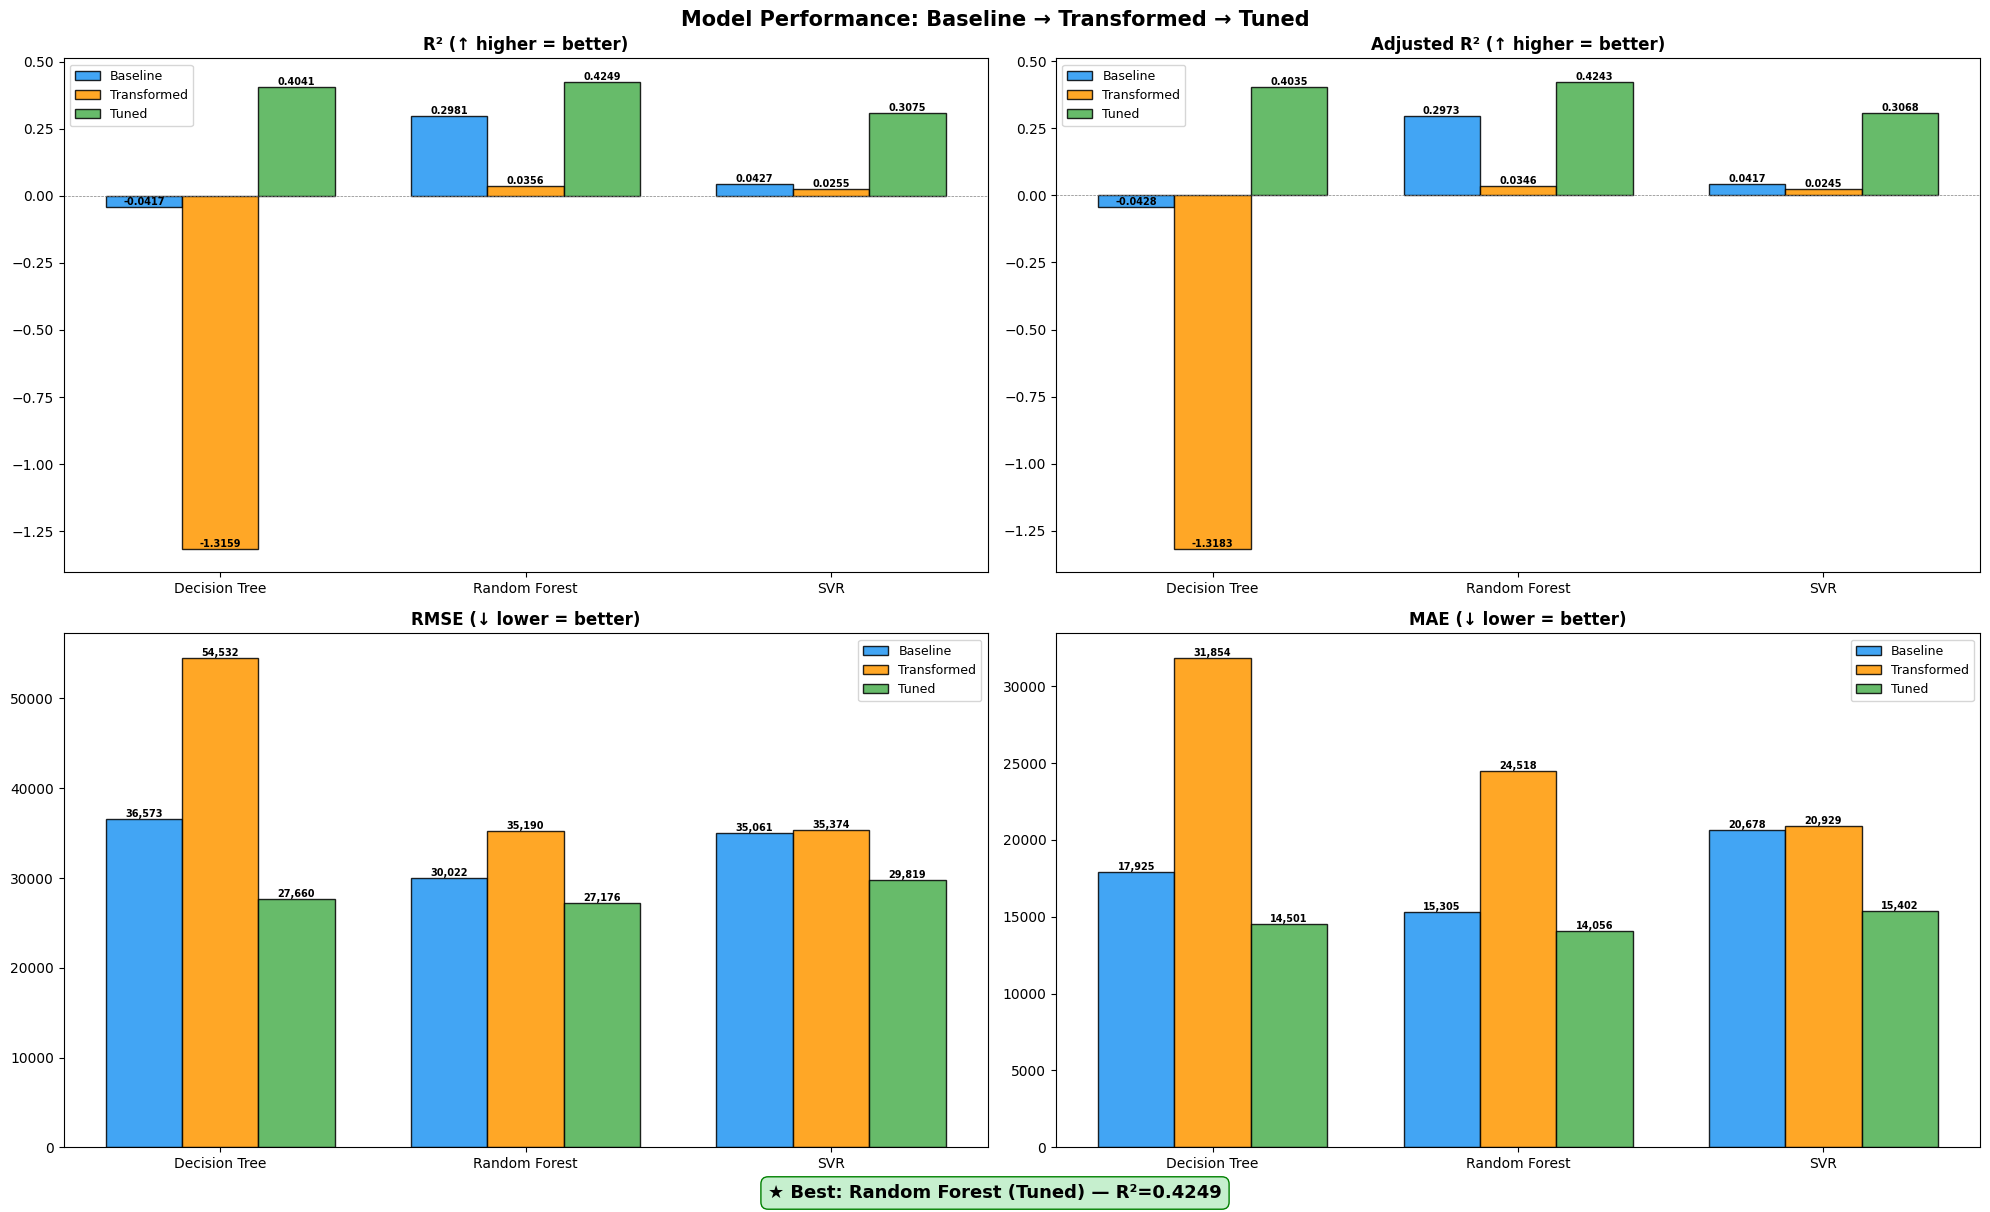

In [29]:
  # Performance: Baseline → Transformed → Tuned
  fig, axes = plt.subplots(2, 2, figsize=(20, 12))
  metrics_list = [('R2', 'R² (↑ higher = better)'), ('Adj_R2', 'Adjusted R² (↑ higher = better)'),
                  ('RMSE', 'RMSE (↓ lower = better)'), ('MAE', 'MAE (↓ lower = better)')]
  stage_colors = {'Baseline': '#2196F3', 'Transformed': '#FF9800', 'Tuned': '#4CAF50'}
  stages_list = ['Baseline', 'Transformed', 'Tuned']

  for idx, (metric, title) in enumerate(metrics_list):
      ax = axes[idx // 2][idx % 2]
      x = np.arange(len(model_names))
      width = 0.25

      for j, stage in enumerate(stages_list):
          vals = summary_df.xs(stage, level='Stage')[metric].values
          bars = ax.bar(x + j * width, vals, width, label=stage,
                        color=stage_colors[stage], edgecolor='black', alpha=0.85)
          for bar, v in zip(bars, vals):
              fmt = f'{v:.4f}' if metric in ['R2', 'Adj_R2'] else f'{v:,.0f}'
              ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                      fmt, ha='center', va='bottom', fontsize=7, fontweight='bold')

      ax.set_xticks(x + width)
      ax.set_xticklabels(model_names, fontsize=10)
      ax.set_title(title, fontsize=12, fontweight='bold')
      ax.legend(fontsize=9)
      if metric in ['R2', 'Adj_R2']:
          ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.5)

  best = summary_df.xs('Tuned', level='Stage')['R2']
  best_name = best.idxmax()
  fig.suptitle('Model Performance: Baseline → Transformed → Tuned', fontsize=15, fontweight='bold')
  fig.text(0.5, -0.01,
           f'★ Best: {best_name} (Tuned) — R²={best[best_name]:.4f}',
           ha='center', fontsize=13, fontweight='bold',
           bbox=dict(boxstyle='round,pad=0.4', facecolor='#c6efce', edgecolor='green'))
  plt.tight_layout()
  plt.show()

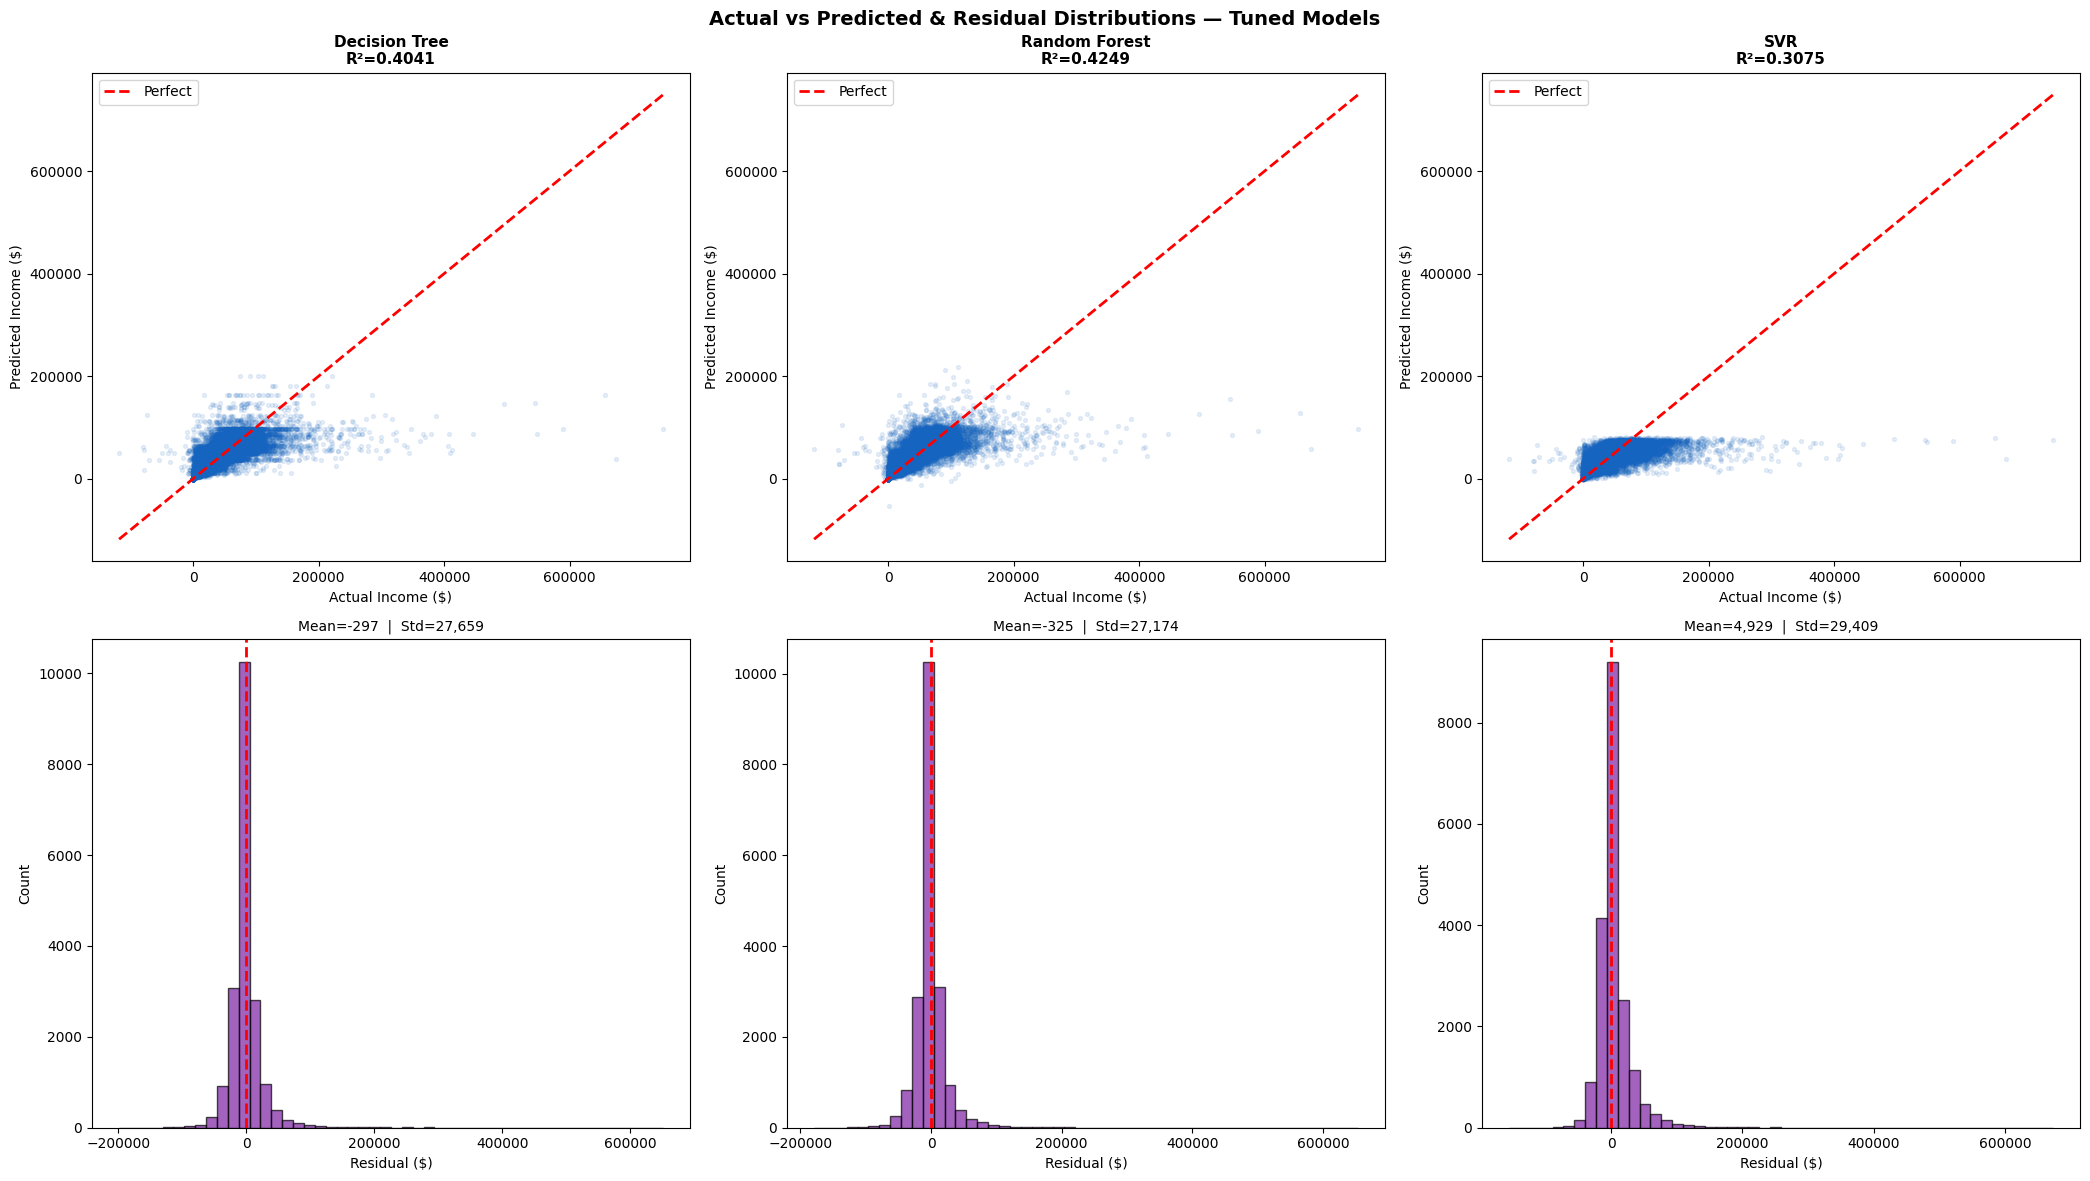

In [31]:
# Actual vs Predicted + Residual Distributions
preds = {'Decision Tree': dt_pred, 'Random Forest': rf_pred, 'SVR': svr_pred}

fig, axes = plt.subplots(2, 3, figsize=(21, 12))
for idx, (name, y_p) in enumerate(preds.items()):
  residuals = y_test.values - y_p
  r2 = tuned_map[name]['R2']

  # Row 1: Actual vs Predicted
  axes[0][idx].scatter(y_test, y_p, alpha=0.1, s=8, color='#1565C0')
  lims = [min(y_test.min(), y_p.min()), max(y_test.max(), y_p.max())]
  axes[0][idx].plot(lims, lims, 'r--', lw=2, label='Perfect')
  axes[0][idx].set_xlabel('Actual Income ($)')
  axes[0][idx].set_ylabel('Predicted Income ($)')
  axes[0][idx].set_title(f'{name}\nR²={r2}', fontsize=11, fontweight='bold')
  axes[0][idx].legend()

  # Row 2: Residual distribution
  axes[1][idx].hist(residuals, bins=50, edgecolor='black', alpha=0.7, color='#7B1FA2')
  axes[1][idx].axvline(0, color='red', linestyle='--', lw=2)
  axes[1][idx].set_xlabel('Residual ($)')
  axes[1][idx].set_ylabel('Count')
  axes[1][idx].set_title(f'Mean={np.mean(residuals):,.0f}  |  Std={np.std(residuals):,.0f}', fontsize=10)

fig.suptitle('Actual vs Predicted & Residual Distributions — Tuned Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'DT Feature Importance')

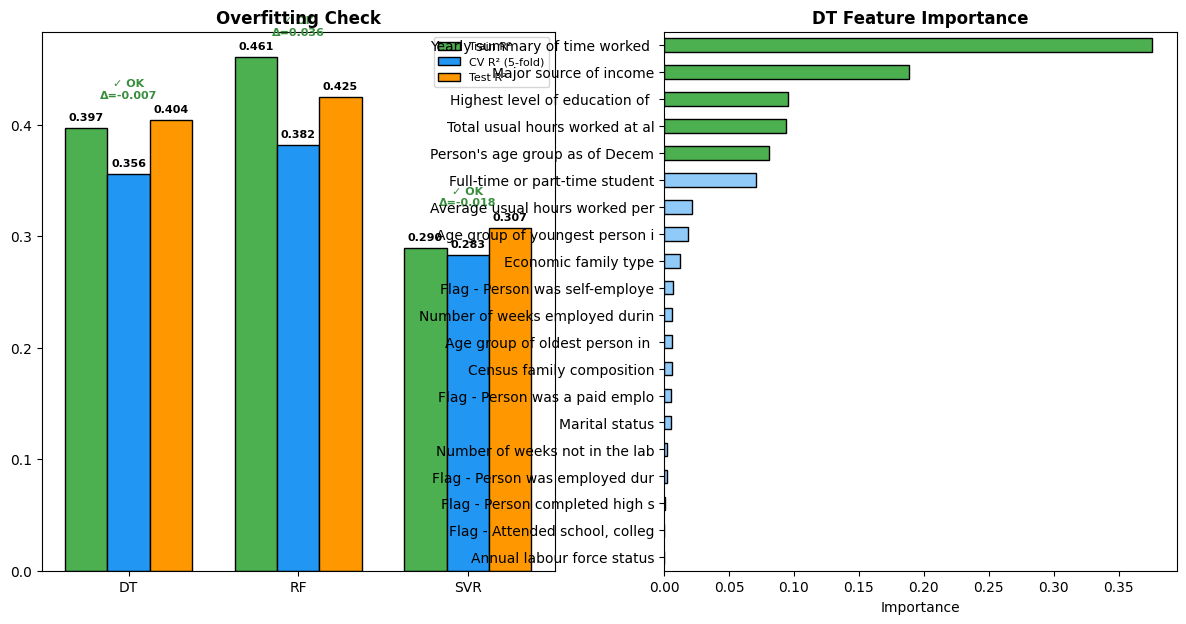

In [32]:
# Overfitting Check + Feature Importance
fig = plt.figure(figsize=(24, 7))
gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 1.2])

# Panel 1: Train vs CV vs Test R²
ax1 = fig.add_subplot(gs[0])
grids = {'Decision Tree': dt_grid, 'Random Forest': rf_grid, 'SVR': svr_grid}
x = np.arange(3)
w = 0.25

train_r2 = [g.cv_results_['mean_train_score'][g.best_index_] for g in grids.values()]
cv_r2 = [g.best_score_ for g in grids.values()]
test_r2 = [tuned_map[m]['R2'] for m in grids]

b1 = ax1.bar(x - w, train_r2, w, label='Train R²', color='#4CAF50', edgecolor='black')
b2 = ax1.bar(x, cv_r2, w, label='CV R² (5-fold)', color='#2196F3', edgecolor='black')
b3 = ax1.bar(x + w, test_r2, w, label='Test R²', color='#FF9800', edgecolor='black')

for bars in [b1, b2, b3]:
  for bar in bars:
      ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
               f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

for i, name in enumerate(grids):
  gap = train_r2[i] - test_r2[i]
  lbl = '⚠ Overfit' if gap > 0.1 else '✓ OK'
  clr = '#D32F2F' if gap > 0.1 else '#388E3C'
  ax1.annotate(f'{lbl}\nΔ={gap:.3f}', xy=(i, max(train_r2[i], test_r2[i]) + 0.02),
               ha='center', fontsize=8, fontweight='bold', color=clr)

ax1.set_xticks(x)
ax1.set_xticklabels(['DT', 'RF', 'SVR'], fontsize=10)
ax1.set_title('Overfitting Check', fontsize=12, fontweight='bold')
ax1.legend(fontsize=8)

# Panel 2: DT Feature Importance
ax2 = fig.add_subplot(gs[1])
imp_dt = pd.Series(dt_best.feature_importances_, index=[f[:30] for f in features]).sort_values()
colors_dt = ['#4CAF50' if v >= imp_dt.quantile(0.75) else '#90CAF9' for v in imp_dt]
imp_dt.plot(kind='barh', ax=ax2, color=colors_dt, edgecolor='black')
ax2.set_xlabel('Importance')
ax2.set_title('DT Feature Importance', fontsize=12, fontweight='bold')

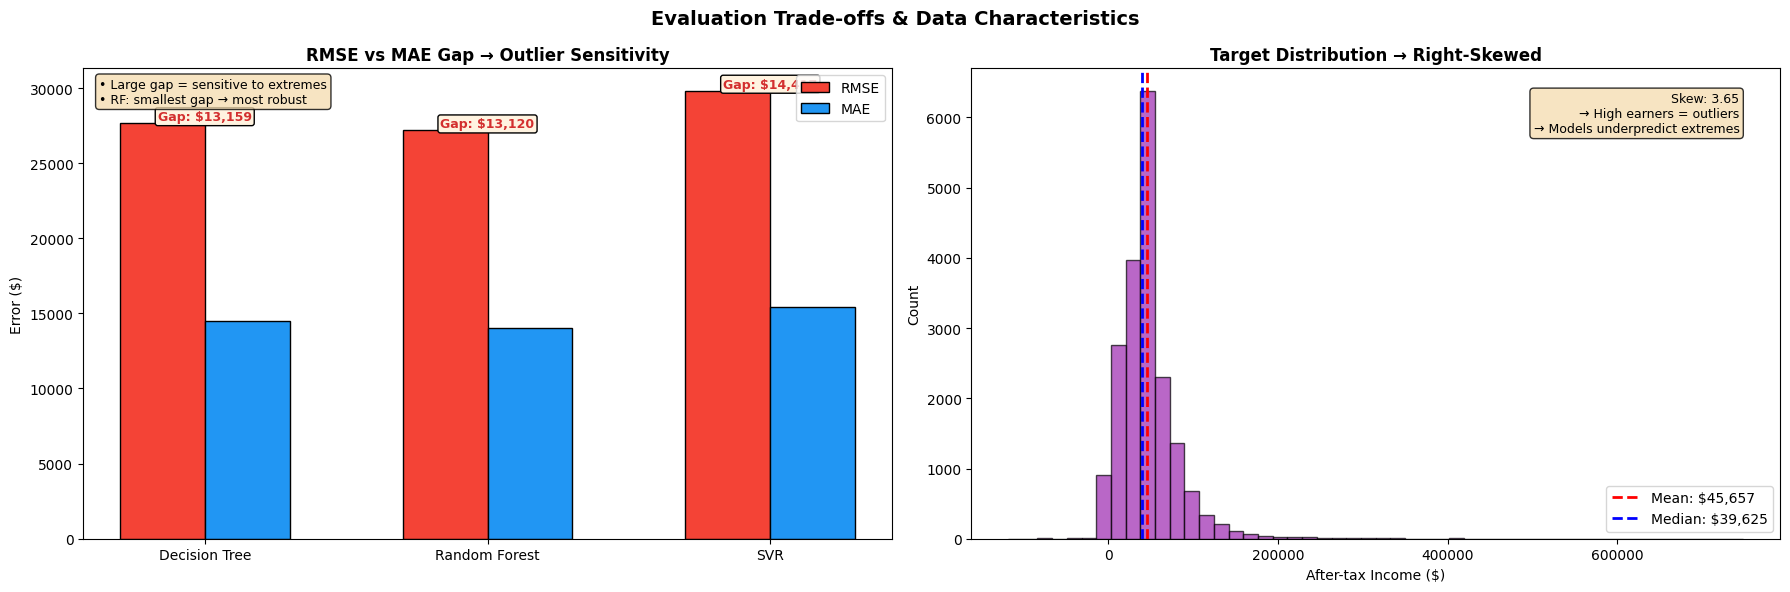

In [34]:
# Evaluation Trade-offs & Data Characteristics
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Panel 1: RMSE vs MAE gap → outlier sensitivity
ax = axes[0]
tuned_only = summary_df.xs('Tuned', level='Stage')
rmse_vals = tuned_only['RMSE'].values
mae_vals = tuned_only['MAE'].values
gap = rmse_vals - mae_vals

x = np.arange(3)
w = 0.3
ax.bar(x - w/2, rmse_vals, w, label='RMSE', color='#F44336', edgecolor='black')
ax.bar(x + w/2, mae_vals, w, label='MAE', color='#2196F3', edgecolor='black')

for i in range(3):
  ax.annotate(f'Gap: ${gap[i]:,.0f}', xy=(i, rmse_vals[i] + 200),
              ha='center', fontsize=9, fontweight='bold', color='#D32F2F',
              bbox=dict(boxstyle='round,pad=0.2', facecolor='#fff3e0'))

ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.set_ylabel('Error ($)')
ax.set_title('RMSE vs MAE Gap → Outlier Sensitivity', fontsize=12, fontweight='bold')
ax.legend()
ax.text(0.02, 0.98, '• Large gap = sensitive to extremes\n• RF: smallest gap → most robust',
      transform=ax.transAxes, va='top', fontsize=9,
      bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# Panel 2: Target distribution (skewness)
ax2 = axes[1]
ax2.hist(y_test, bins=50, edgecolor='black', alpha=0.7, color='#9C27B0')
ax2.axvline(y_test.mean(), color='red', linestyle='--', lw=2, label=f'Mean: ${y_test.mean():,.0f}')
ax2.axvline(y_test.median(), color='blue', linestyle='--', lw=2, label=f'Median: ${y_test.median():,.0f}')
ax2.set_xlabel('After-tax Income ($)')
ax2.set_ylabel('Count')
ax2.set_title('Target Distribution → Right-Skewed', fontsize=12, fontweight='bold')
ax2.legend()
ax2.text(0.95, 0.95, f'Skew: {y_test.skew():.2f}\n→ High earners = outliers\n→ Models underpredict extremes',
       transform=ax2.transAxes, va='top', ha='right', fontsize=9,
       bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.suptitle('Evaluation Trade-offs & Data Characteristics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

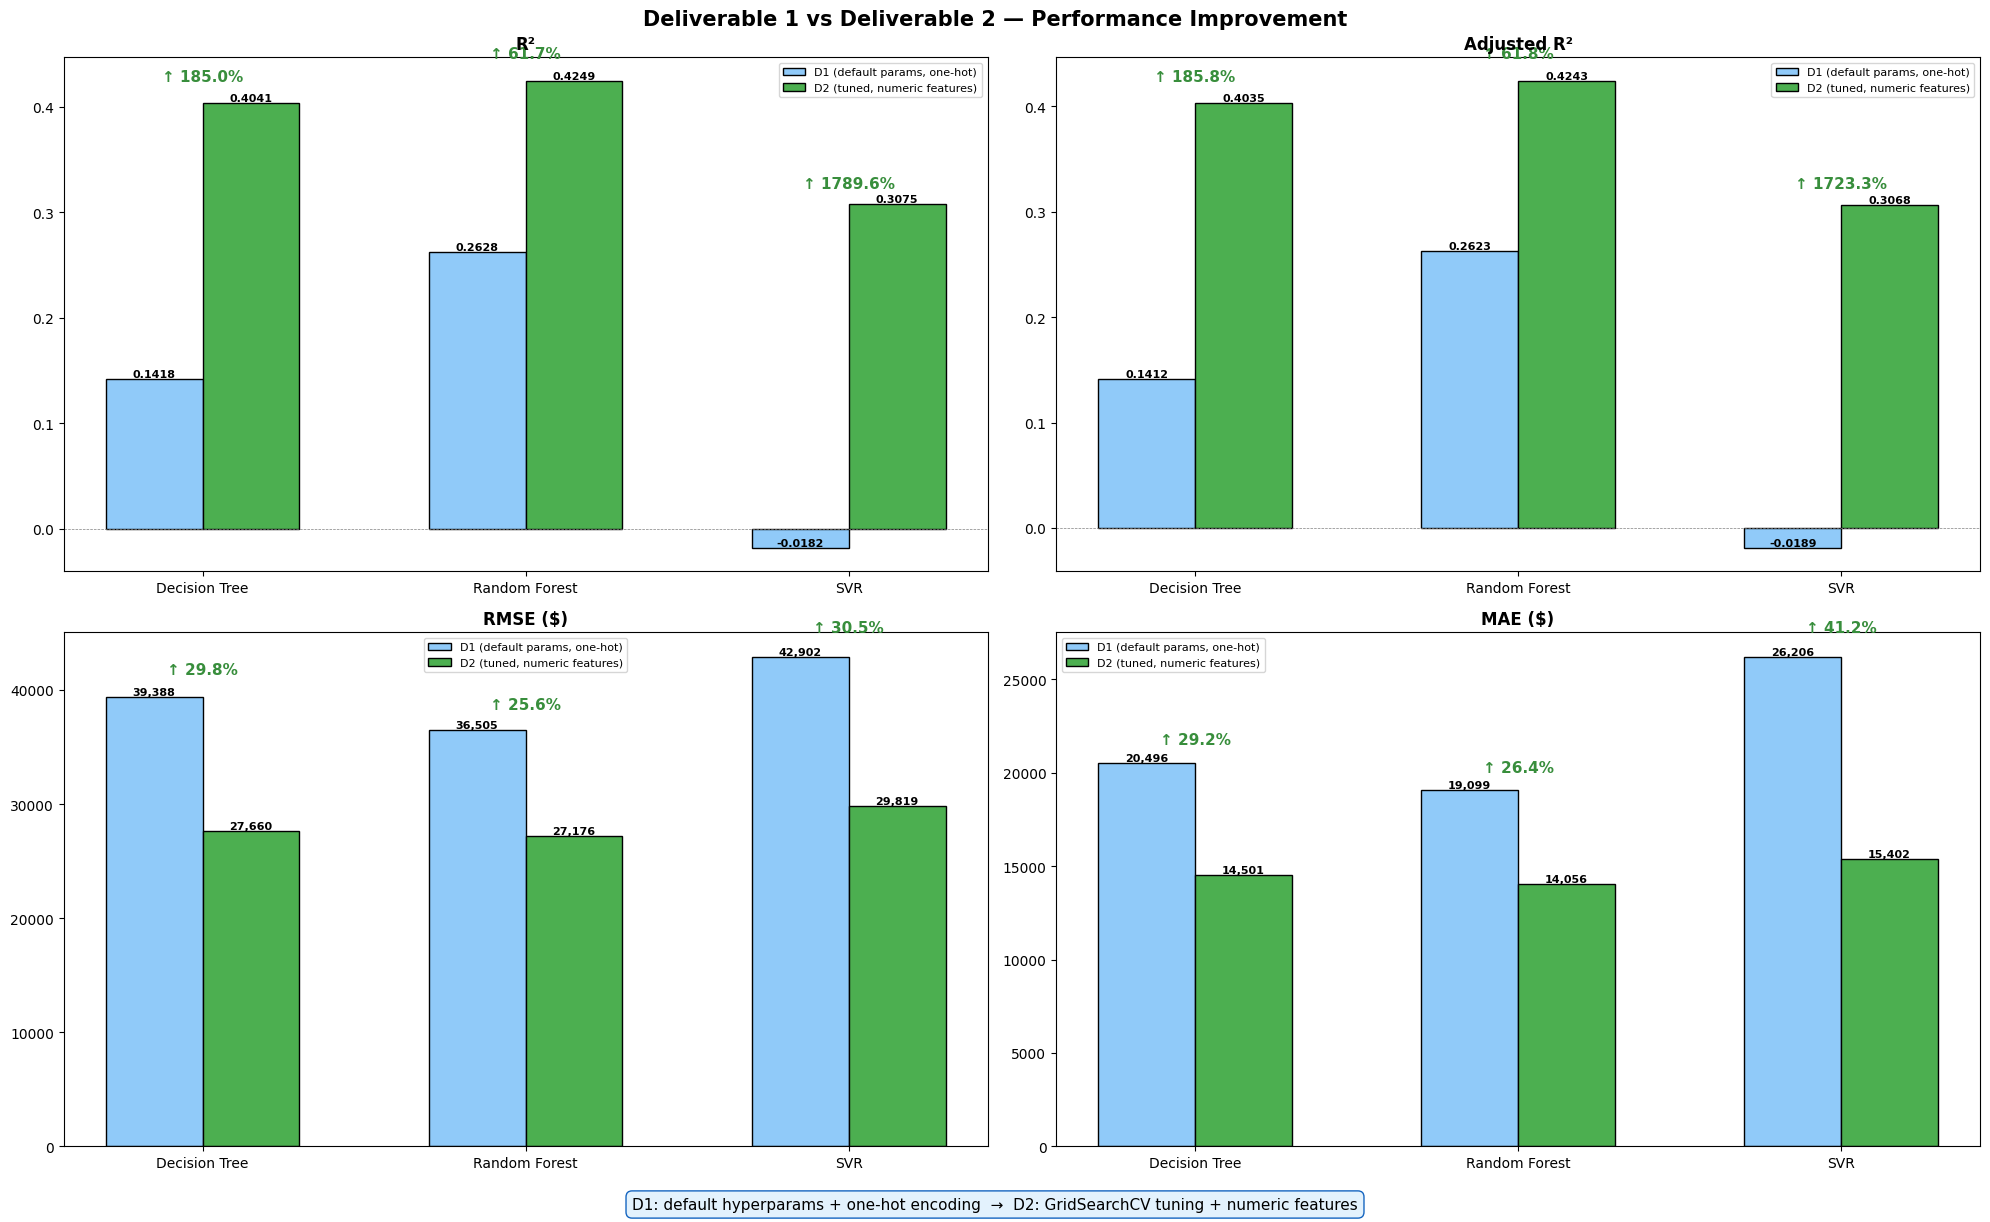

In [35]:
  # Deliverable 1 vs Deliverable 2 Comparison
  d1 = {
      'Decision Tree': {'R2': 0.1418, 'Adj_R2': 0.1412, 'RMSE': 39387.53, 'MAE': 20496.00},
      'Random Forest': {'R2': 0.2628, 'Adj_R2': 0.2623, 'RMSE': 36504.98, 'MAE': 19098.95},
      'SVR':           {'R2': -0.0182, 'Adj_R2': -0.0189, 'RMSE': 42901.87, 'MAE': 26206.42},
  }
  d2 = tuned_map

  shared = ['Decision Tree', 'Random Forest', 'SVR']
  fig, axes = plt.subplots(2, 2, figsize=(20, 12))
  metrics_info = [('R2', 'R²', True), ('Adj_R2', 'Adjusted R²', True),
                  ('RMSE', 'RMSE ($)', False), ('MAE', 'MAE ($)', False)]

  for idx, (metric, label, higher_better) in enumerate(metrics_info):
      ax = axes[idx // 2][idx % 2]
      x = np.arange(len(shared))
      w = 0.3

      d1_vals = [d1[m][metric] for m in shared]
      d2_vals = [d2[m][metric] for m in shared]

      ax.bar(x - w/2, d1_vals, w, label='D1 (default params, one-hot)',
             color='#90CAF9', edgecolor='black')
      ax.bar(x + w/2, d2_vals, w, label='D2 (tuned, numeric features)',
             color='#4CAF50', edgecolor='black')

      for i in range(len(shared)):
          fmt = f'{d1_vals[i]:.4f}' if higher_better else f'{d1_vals[i]:,.0f}'
          ax.text(i - w/2, d1_vals[i], fmt, ha='center', va='bottom', fontsize=8, fontweight='bold')
          fmt2 = f'{d2_vals[i]:.4f}' if higher_better else f'{d2_vals[i]:,.0f}'
          ax.text(i + w/2, d2_vals[i], fmt2, ha='center', va='bottom', fontsize=8, fontweight='bold')

      for i, m in enumerate(shared):
          d1v, d2v = d1[m][metric], d2[m][metric]
          if higher_better:
              improved = d2v > d1v
              pct = abs((d2v - d1v) / abs(d1v)) * 100 if d1v != 0 else 0
          else:
              improved = d2v < d1v
              pct = abs((d1v - d2v) / d1v) * 100 if d1v != 0 else 0

          arrow = '↑' if improved else '↓'
          clr = '#388E3C' if improved else '#D32F2F'
          y_pos = max(d1v, d2v) * (1.05 if max(d1v, d2v) > 0 else 0.95)
          ax.annotate(f'{arrow} {pct:.1f}%', xy=(i, y_pos),
                      ha='center', fontsize=11, fontweight='bold', color=clr)

      ax.set_xticks(x)
      ax.set_xticklabels(shared, fontsize=10)
      ax.set_title(label, fontsize=12, fontweight='bold')
      ax.legend(fontsize=8, loc='best')
      if metric in ['R2', 'Adj_R2']:
          ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.5)

  fig.suptitle('Deliverable 1 vs Deliverable 2 — Performance Improvement', fontsize=15, fontweight='bold')
  fig.text(0.5, -0.02,
           'D1: default hyperparams + one-hot encoding  →  D2: GridSearchCV tuning + numeric features',
           ha='center', fontsize=11,
           bbox=dict(boxstyle='round,pad=0.4', facecolor='#E3F2FD', edgecolor='#1565C0'))
  plt.tight_layout()
  plt.show()

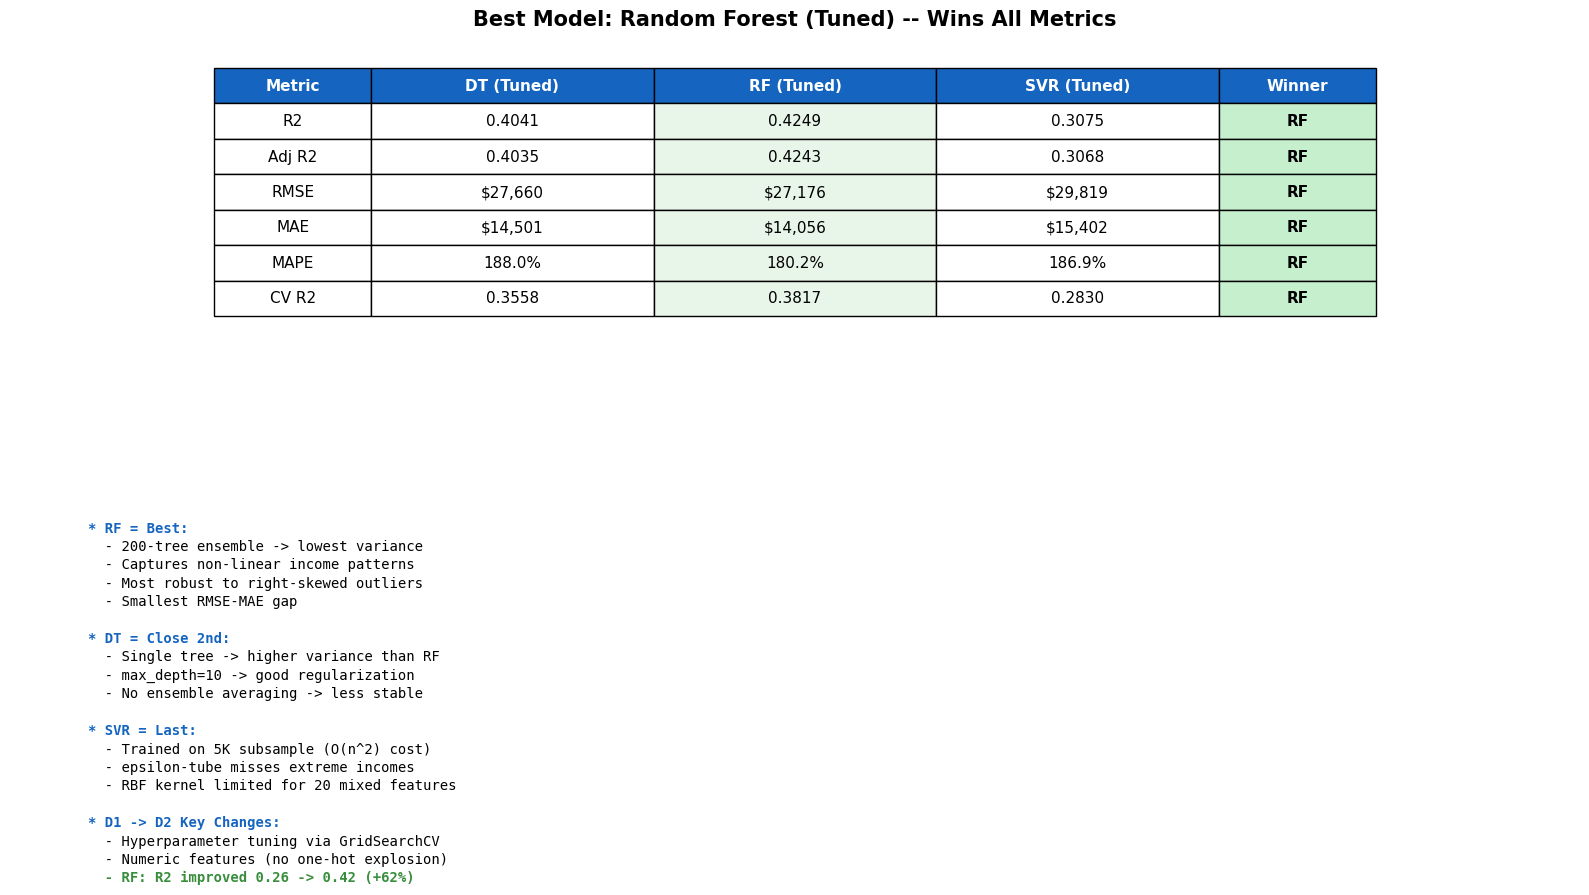

In [39]:
# Best Model Selection — Final Summary
fig, ax = plt.subplots(figsize=(16, 9))
ax.axis('off')

summary_data = [
  ['Metric', 'DT (Tuned)', 'RF (Tuned)', 'SVR (Tuned)', 'Winner'],
  ['R2', f'{dt_tuned_results["R2"]:.4f}', f'{rf_tuned_results["R2"]:.4f}', f'{svr_tuned_results["R2"]:.4f}', 'RF'],
  ['Adj R2', f'{dt_tuned_results["Adj_R2"]:.4f}', f'{rf_tuned_results["Adj_R2"]:.4f}',
f'{svr_tuned_results["Adj_R2"]:.4f}', 'RF'],
  ['RMSE', f'${float(dt_tuned_results["RMSE"]):,.0f}', f'${float(rf_tuned_results["RMSE"]):,.0f}',
f'${float(svr_tuned_results["RMSE"]):,.0f}', 'RF'],
  ['MAE', f'${float(dt_tuned_results["MAE"]):,.0f}', f'${float(rf_tuned_results["MAE"]):,.0f}',
f'${float(svr_tuned_results["MAE"]):,.0f}', 'RF'],
  ['MAPE', f'{float(dt_tuned_results["MAPE"]):.1f}%', f'{float(rf_tuned_results["MAPE"]):.1f}%',
f'{float(svr_tuned_results["MAPE"]):.1f}%', 'RF'],
  ['CV R2', f'{dt_grid.best_score_:.4f}', f'{rf_grid.best_score_:.4f}', f'{svr_grid.best_score_:.4f}', 'RF'],
]

table = ax.table(cellText=summary_data[1:], colLabels=summary_data[0],
               cellLoc='center', loc='upper center', colWidths=[0.1, 0.18, 0.18, 0.18, 0.1])
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2)

for j in range(5):
  table[0, j].set_facecolor('#1565C0')
  table[0, j].set_text_props(color='white', fontweight='bold')
for i in range(1, 7):
  table[i, 4].set_facecolor('#c6efce')
  table[i, 4].set_text_props(fontweight='bold')
  table[i, 2].set_facecolor('#E8F5E9')

ax.set_title('Best Model: Random Forest (Tuned) -- Wins All Metrics',
           fontsize=15, fontweight='bold', pad=20)

reasons = [
  ('* RF = Best:', '#1565C0', 'bold'),
  ('  - 200-tree ensemble -> lowest variance', 'black', 'normal'),
  ('  - Captures non-linear income patterns', 'black', 'normal'),
  ('  - Most robust to right-skewed outliers', 'black', 'normal'),
  ('  - Smallest RMSE-MAE gap', 'black', 'normal'),
  ('', 'black', 'normal'),
  ('* DT = Close 2nd:', '#1565C0', 'bold'),
  ('  - Single tree -> higher variance than RF', 'black', 'normal'),
  ('  - max_depth=10 -> good regularization', 'black', 'normal'),
  ('  - No ensemble averaging -> less stable', 'black', 'normal'),
  ('', 'black', 'normal'),
  ('* SVR = Last:', '#1565C0', 'bold'),
  ('  - Trained on 5K subsample (O(n^2) cost)', 'black', 'normal'),
  ('  - epsilon-tube misses extreme incomes', 'black', 'normal'),
  ('  - RBF kernel limited for 20 mixed features', 'black', 'normal'),
  ('', 'black', 'normal'),
  ('* D1 -> D2 Key Changes:', '#1565C0', 'bold'),
  ('  - Hyperparameter tuning via GridSearchCV', 'black', 'normal'),
  ('  - Numeric features (no one-hot explosion)', 'black', 'normal'),
  ('  - RF: R2 improved 0.26 -> 0.42 (+62%)', '#388E3C', 'bold'),
]

y_start = 0.35
for i, (line, color, weight) in enumerate(reasons):
  ax.text(0.05, y_start - i * 0.025, line, transform=ax.transAxes,
          fontsize=10, fontweight=weight, color=color, family='monospace')

plt.tight_layout()
plt.show()